In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
DATA_PATH = Path("data") / "breast_cancer_wisconsin.csv"
print("Dataset path:", DATA_PATH)
print("File available:", DATA_PATH.exists())

Dataset path: data\breast_cancer_wisconsin.csv
File available: True


In [3]:
uci_column_names = [
    "id",
    "diagnosis",

    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

print("Number of defined columns:", len(uci_column_names))

Number of defined columns: 32


In [4]:
breast_cancer_df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=uci_column_names
)

print("UCI Breast Cancer Wisconsin dataset loaded successfully.")

UCI Breast Cancer Wisconsin dataset loaded successfully.


In [5]:
breast_cancer_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
number_of_rows, number_of_columns = breast_cancer_df.shape

print("Number of instances:", number_of_rows)
print("Total number of columns:", number_of_columns)
print("Number of input features:", number_of_columns - 2)

Number of instances: 569
Total number of columns: 32
Number of input features: 30


In [7]:
minimum_instances_required = 500
minimum_features_required = 12

actual_instances = breast_cancer_df.shape[0]
actual_features = breast_cancer_df.shape[1] - 2

print("Instances available:", actual_instances)
print("Features available:", actual_features)

print(
    "Instance requirement satisfied:",
    actual_instances >= minimum_instances_required
)

print(
    "Feature requirement satisfied:",
    actual_features >= minimum_features_required
)

Instances available: 569
Features available: 30
Instance requirement satisfied: True
Feature requirement satisfied: True


In [8]:
print("Columns in the dataset:\n")

for column_number, column_name in enumerate(
    breast_cancer_df.columns,
    start=1
):
    print(f"{column_number}. {column_name}")

Columns in the dataset:

1. id
2. diagnosis
3. radius_mean
4. texture_mean
5. perimeter_mean
6. area_mean
7. smoothness_mean
8. compactness_mean
9. concavity_mean
10. concave_points_mean
11. symmetry_mean
12. fractal_dimension_mean
13. radius_se
14. texture_se
15. perimeter_se
16. area_se
17. smoothness_se
18. compactness_se
19. concavity_se
20. concave_points_se
21. symmetry_se
22. fractal_dimension_se
23. radius_worst
24. texture_worst
25. perimeter_worst
26. area_worst
27. smoothness_worst
28. compactness_worst
29. concavity_worst
30. concave_points_worst
31. symmetry_worst
32. fractal_dimension_worst


In [9]:
breast_cancer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [10]:
total_missing_values = breast_cancer_df.isnull().sum().sum()

print("Total missing values:", total_missing_values)

Total missing values: 0


In [11]:
print("Unique diagnosis values:")
print(breast_cancer_df["diagnosis"].unique())

Unique diagnosis values:
<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str


In [12]:
diagnosis_counts = breast_cancer_df["diagnosis"].value_counts()

print("Diagnosis class distribution:")
print(diagnosis_counts)

Diagnosis class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [13]:
diagnosis_percentages = (
    breast_cancer_df["diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Diagnosis distribution in percentage:")
print(diagnosis_percentages)

Diagnosis distribution in percentage:
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [14]:
duplicate_row_count = breast_cancer_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_row_count)

Number of duplicate rows: 0


In [15]:
duplicate_id_count = breast_cancer_df["id"].duplicated().sum()

print("Number of duplicate IDs:", duplicate_id_count)

Number of duplicate IDs: 0


In [16]:
breast_cancer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [17]:
assert DATA_PATH.exists(), (
    "Dataset file was not found at the specified location."
)

assert breast_cancer_df.shape[0] >= 500, (
    "The dataset does not satisfy the minimum instance requirement."
)

assert breast_cancer_df.shape[1] - 2 >= 12, (
    "The dataset does not satisfy the minimum feature requirement."
)

assert "diagnosis" in breast_cancer_df.columns, (
    "The target column 'diagnosis' is missing."
)

assert breast_cancer_df["diagnosis"].nunique() == 2, (
    "The diagnosis column must contain exactly two classes."
)

assert breast_cancer_df.isnull().sum().sum() == 0, (
    "Missing values were found in the dataset."
)

assert breast_cancer_df["id"].is_unique, (
    "Duplicate patient IDs were found."
)

assert set(breast_cancer_df["diagnosis"].unique()) == {"B", "M"}, (
    "Unexpected diagnosis labels were found."
)

print("All initial dataset validation checks passed successfully.")

All initial dataset validation checks passed successfully.


In [18]:
usable_feature_count = breast_cancer_df.shape[1] - 2

print("UCI DATASET INITIAL INSPECTION")
print("=" * 45)
print(f"Dataset name          : Breast Cancer Wisconsin Diagnostic")
print(f"Dataset source        : UCI Machine Learning Repository")
print(f"Dataset shape         : {breast_cancer_df.shape}")
print(f"Number of instances   : {breast_cancer_df.shape[0]}")
print(f"Input feature count   : {usable_feature_count}")
print(f"Target column         : diagnosis")
print(f"Target classes        : {breast_cancer_df['diagnosis'].unique()}")
print(f"Missing values        : {breast_cancer_df.isnull().sum().sum()}")
print(f"Duplicate rows        : {breast_cancer_df.duplicated().sum()}")
print(f"Duplicate IDs         : {breast_cancer_df['id'].duplicated().sum()}")
print("=" * 45)
print("Dataset is ready for the cleaning and preprocessing stage.")

UCI DATASET INITIAL INSPECTION
Dataset name          : Breast Cancer Wisconsin Diagnostic
Dataset source        : UCI Machine Learning Repository
Dataset shape         : (569, 32)
Number of instances   : 569
Input feature count   : 30
Target column         : diagnosis
Target classes        : <ArrowStringArray>
['M', 'B']
Length: 2, dtype: str
Missing values        : 0
Duplicate rows        : 0
Duplicate IDs         : 0
Dataset is ready for the cleaning and preprocessing stage.


In [19]:
prepared_cancer_df = breast_cancer_df.copy()

print("Working copy created successfully.")
print("Shape of working dataset:", prepared_cancer_df.shape)

Working copy created successfully.
Shape of working dataset: (569, 32)


In [20]:
prepared_cancer_df = prepared_cancer_df.drop(columns=["id"])

print("ID column removed successfully.")
print("Updated shape:", prepared_cancer_df.shape)

ID column removed successfully.
Updated shape: (569, 31)


In [21]:
print("Number of remaining columns:", prepared_cancer_df.shape[1])
print("Diagnosis column available:", "diagnosis" in prepared_cancer_df.columns)
print("ID column available:", "id" in prepared_cancer_df.columns)

Number of remaining columns: 31
Diagnosis column available: True
ID column available: False


In [22]:
diagnosis_mapping = {
    "B": 0,
    "M": 1
}

prepared_cancer_df["diagnosis"] = (
    prepared_cancer_df["diagnosis"]
    .map(diagnosis_mapping)
)

print("Diagnosis target encoded successfully.")
print(prepared_cancer_df["diagnosis"].value_counts())

Diagnosis target encoded successfully.
diagnosis
0    357
1    212
Name: count, dtype: int64


In [23]:
print("Unique encoded target values:")
print(prepared_cancer_df["diagnosis"].unique())

print("\nTarget data type:")
print(prepared_cancer_df["diagnosis"].dtype)

print("\nMissing values after encoding:")
print(prepared_cancer_df["diagnosis"].isnull().sum())

Unique encoded target values:
[1 0]

Target data type:
int64

Missing values after encoding:
0


In [24]:
non_numeric_columns = (
    prepared_cancer_df
    .drop(columns=["diagnosis"])
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

print("Non-numeric feature columns:", non_numeric_columns)

Non-numeric feature columns: []


In [25]:
total_missing_values = prepared_cancer_df.isnull().sum().sum()

print("Total missing values after cleaning:", total_missing_values)

Total missing values after cleaning: 0


In [26]:
duplicate_rows_after_cleaning = prepared_cancer_df.duplicated().sum()

print(
    "Duplicate rows after removing ID:",
    duplicate_rows_after_cleaning
)

Duplicate rows after removing ID: 0


In [27]:
feature_data = prepared_cancer_df.drop(columns=["diagnosis"])
target_data = prepared_cancer_df["diagnosis"]

print("Feature dataset shape:", feature_data.shape)
print("Target dataset shape:", target_data.shape)

Feature dataset shape: (569, 30)
Target dataset shape: (569,)


In [28]:
assert feature_data.shape[0] == target_data.shape[0], (
    "The number of feature records and target labels must be equal."
)

assert feature_data.shape[1] == 30, (
    "The dataset should contain exactly 30 input features."
)

assert target_data.nunique() == 2, (
    "The target should contain exactly two classes."
)

assert set(target_data.unique()) == {0, 1}, (
    "The encoded target should contain only 0 and 1."
)

assert feature_data.isnull().sum().sum() == 0, (
    "Missing values were found in the feature dataset."
)

print("Feature and target validation completed successfully.")

Feature and target validation completed successfully.


In [29]:
class_distribution = pd.DataFrame({
    "Diagnosis": ["Benign", "Malignant"],
    "Encoded Value": [0, 1],
    "Number of Records": [
        (target_data == 0).sum(),
        (target_data == 1).sum()
    ],
    "Percentage": [
        round((target_data == 0).mean() * 100, 2),
        round((target_data == 1).mean() * 100, 2)
    ]
})

class_distribution

,Diagnosis,Encoded Value,Number of Records,Percentage
0,Benign,0,357,62.74
1,Malignant,1,212,37.26


In [30]:
import matplotlib.pyplot as plt

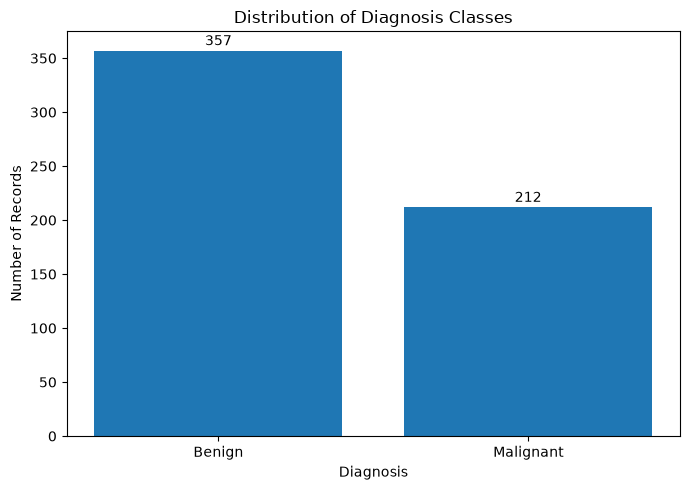

In [31]:
class_names = target_data.map({
    0: "Benign",
    1: "Malignant"
})

class_counts = class_names.value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("Distribution of Diagnosis Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Records")

for bar in bars:
    bar_height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar_height + 5,
        str(int(bar_height)),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    feature_data,
    target_data,
    test_size=0.20,
    random_state=17,
    stratify=target_data
)

print("Train-test split completed successfully.")

Train-test split completed successfully.


In [34]:
print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)

Training feature shape: (455, 30)
Testing feature shape : (114, 30)
Training target shape : (455,)
Testing target shape  : (114,)


In [35]:
def display_class_proportions(dataset_name, target_values):
    benign_percentage = (target_values == 0).mean() * 100
    malignant_percentage = (target_values == 1).mean() * 100

    print(dataset_name)
    print(f"  Benign percentage   : {benign_percentage:.2f}%")
    print(f"  Malignant percentage: {malignant_percentage:.2f}%")
    print()


display_class_proportions("Complete dataset", target_data)
display_class_proportions("Training dataset", y_train)
display_class_proportions("Testing dataset", y_test)

Complete dataset
  Benign percentage   : 62.74%
  Malignant percentage: 37.26%

Training dataset
  Benign percentage   : 62.64%
  Malignant percentage: 37.36%

Testing dataset
  Benign percentage   : 63.16%
  Malignant percentage: 36.84%



In [36]:
print(
    "Testing feature and target indices match:",
    X_test.index.equals(y_test.index)
)

Testing feature and target indices match: True


In [37]:
test_data_for_app = X_test.copy()

test_data_for_app["diagnosis"] = y_test

print("Test data shape:", test_data_for_app.shape)
test_data_for_app.head()

Test data shape: (114, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
196,13.77,22.29,90.63,588.9,0.12000,0.12670,0.13850,0.06526,0.1834,0.06877,...,34.01,111.6,806.9,0.1737,0.3122,0.3809,0.1673,0.3080,0.09333,1
92,13.27,14.76,84.74,551.7,0.07355,0.05055,0.03261,0.02648,0.1386,0.05318,...,22.35,104.5,830.6,0.1006,0.1238,0.1350,0.1001,0.2027,0.06206,0
219,19.53,32.47,128.00,1223.0,0.08420,0.11300,0.11450,0.06637,0.1428,0.05313,...,45.41,180.2,2477.0,0.1408,0.4097,0.3995,0.1625,0.2713,0.07568,1
111,12.63,20.76,82.15,480.4,0.09933,0.12090,0.10650,0.06021,0.1735,0.07070,...,25.47,89.0,527.4,0.1287,0.2250,0.2216,0.1105,0.2226,0.08486,0
257,15.32,17.27,103.20,713.3,0.13350,0.22840,0.24480,0.12420,0.2398,0.07596,...,22.66,119.8,928.8,0.1765,0.4503,0.4429,0.2229,0.3258,0.11910,1


In [38]:
test_data_for_app["diagnosis"] = (
    test_data_for_app["diagnosis"]
    .map({
        0: "B",
        1: "M"
    })
)

print(test_data_for_app["diagnosis"].value_counts())

diagnosis
B    72
M    42
Name: count, dtype: int64


In [39]:
TEST_DATA_PATH = Path("test_data.csv")

test_data_for_app.to_csv(
    TEST_DATA_PATH,
    index=False
)

print("Test data saved successfully.")
print("File path:", TEST_DATA_PATH)
print("File available:", TEST_DATA_PATH.exists())

Test data saved successfully.
File path: test_data.csv
File available: True


In [40]:
saved_test_data = pd.read_csv(TEST_DATA_PATH)

print("Saved test data shape:", saved_test_data.shape)
print("Missing values:", saved_test_data.isnull().sum().sum())
print("Diagnosis values:", saved_test_data["diagnosis"].unique())

saved_test_data.head()

Saved test data shape: (114, 31)
Missing values: 0
Diagnosis values: <ArrowStringArray>
['M', 'B']
Length: 2, dtype: str


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,13.77,22.29,90.63,588.9,0.12000,0.12670,0.13850,0.06526,0.1834,0.06877,...,34.01,111.6,806.9,0.1737,0.3122,0.3809,0.1673,0.3080,0.09333,M
1,13.27,14.76,84.74,551.7,0.07355,0.05055,0.03261,0.02648,0.1386,0.05318,...,22.35,104.5,830.6,0.1006,0.1238,0.1350,0.1001,0.2027,0.06206,B
2,19.53,32.47,128.00,1223.0,0.08420,0.11300,0.11450,0.06637,0.1428,0.05313,...,45.41,180.2,2477.0,0.1408,0.4097,0.3995,0.1625,0.2713,0.07568,M
3,12.63,20.76,82.15,480.4,0.09933,0.12090,0.10650,0.06021,0.1735,0.07070,...,25.47,89.0,527.4,0.1287,0.2250,0.2216,0.1105,0.2226,0.08486,B
4,15.32,17.27,103.20,713.3,0.13350,0.22840,0.24480,0.12420,0.2398,0.07596,...,22.66,119.8,928.8,0.1765,0.4503,0.4429,0.2229,0.3258,0.11910,M


In [41]:
print("DATA PREPARATION SUMMARY")
print("=" * 50)
print(f"Original records               : {breast_cancer_df.shape[0]}")
print(f"Original columns               : {breast_cancer_df.shape[1]}")
print(f"Input features used            : {feature_data.shape[1]}")
print(f"Target variable                : diagnosis")
print(f"Benign encoding                : 0")
print(f"Malignant encoding             : 1")
print(f"Training instances             : {X_train.shape[0]}")
print(f"Testing instances              : {X_test.shape[0]}")
print(f"Training percentage            : {X_train.shape[0] / len(feature_data) * 100:.2f}%")
print(f"Testing percentage             : {X_test.shape[0] / len(feature_data) * 100:.2f}%")
print(f"Random state                   : 17")
print(f"Stratified split               : Yes")
print(f"Missing values                 : {prepared_cancer_df.isnull().sum().sum()}")
print(f"Test CSV created               : {TEST_DATA_PATH.exists()}")
print("=" * 50)
print("The dataset is ready for model implementation.")

DATA PREPARATION SUMMARY
Original records               : 569
Original columns               : 32
Input features used            : 30
Target variable                : diagnosis
Benign encoding                : 0
Malignant encoding             : 1
Training instances             : 455
Testing instances              : 114
Training percentage            : 79.96%
Testing percentage             : 20.04%
Random state                   : 17
Stratified split               : Yes
Missing values                 : 0
Test CSV created               : True
The dataset is ready for model implementation.


Model 1 - Logistic Regression

In [42]:
from pathlib import Path

MODEL_DIRECTORY = Path("model")
MODEL_DIRECTORY.mkdir(exist_ok=True)

init_file_path = MODEL_DIRECTORY / "__init__.py"

init_file_path.write_text(
    '"""Machine learning model definitions for the project."""\n',
    encoding="utf-8"
)

print("Created:", init_file_path)

Created: model\__init__.py


In [43]:
LOGISTIC_MODEL_SOURCE = """
\"\"\"
Logistic Regression model definition.

This module creates a Logistic Regression classification pipeline for the
Breast Cancer Wisconsin Diagnostic dataset.
\"\"\"

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def create_logistic_regression_model(random_state=17):
    \"\"\"
    Create a Logistic Regression classification pipeline.

    StandardScaler is included because the input features have different
    numerical scales. The scaler and classifier are placed in the same
    pipeline to prevent data leakage and maintain consistent preprocessing.

    Parameters
    ----------
    random_state : int, default=17
        Fixed random seed used for reproducibility.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline containing StandardScaler and LogisticRegression.
    \"\"\"

    model_pipeline = Pipeline(
        steps=[
            (
                "feature_scaling",
                StandardScaler()
            ),
            (
                "classifier",
                LogisticRegression(
                    solver="liblinear",
                    max_iter=1000,
                    random_state=random_state
                )
            )
        ]
    )

    return model_pipeline
"""

LOGISTIC_SOURCE_PATH = (
    MODEL_DIRECTORY / "logistic_regression.py"
)

LOGISTIC_SOURCE_PATH.write_text(
    LOGISTIC_MODEL_SOURCE,
    encoding="utf-8"
)

print("Logistic Regression source file created successfully.")
print("File path:", LOGISTIC_SOURCE_PATH)
print("File exists:", LOGISTIC_SOURCE_PATH.exists())

Logistic Regression source file created successfully.
File path: model\logistic_regression.py
File exists: True


In [44]:
from model.logistic_regression import create_logistic_regression_model

print("Logistic Regression model function imported successfully.")

Logistic Regression model function imported successfully.


In [45]:
logistic_regression_model = (
    create_logistic_regression_model(
        random_state=17
    )
)

print("Logistic Regression pipeline created successfully.")
print(logistic_regression_model)

Logistic Regression pipeline created successfully.
Pipeline(steps=[('feature_scaling', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=17,
                                    solver='liblinear'))])


In [46]:
print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training feature shape: (455, 30)
Testing feature shape : (114, 30)
Training target shape : (455,)
Testing target shape  : (114,)

Training target distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Testing target distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [47]:
logistic_regression_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [48]:
logistic_predictions = (
    logistic_regression_model.predict(X_test)
)

print("Class predictions generated successfully.")
print("Number of predictions:", len(logistic_predictions))
print("Unique predicted classes:", set(logistic_predictions))

Class predictions generated successfully.
Number of predictions: 114
Unique predicted classes: {np.int64(0), np.int64(1)}


In [49]:
logistic_probability_matrix = (
    logistic_regression_model.predict_proba(X_test)
)

print("Probability matrix shape:", logistic_probability_matrix.shape)
print("First five probability rows:")
print(logistic_probability_matrix[:5])


Probability matrix shape: (114, 2)
First five probability rows:
[[1.18341288e-03 9.98816587e-01]
 [9.82686374e-01 1.73136261e-02]
 [3.24828142e-09 9.99999997e-01]
 [9.91933607e-01 8.06639318e-03]
 [1.69837940e-03 9.98301621e-01]]


In [50]:
logistic_malignant_probabilities = (
    logistic_probability_matrix[:, 1]
)

print("Number of malignant probability scores:",
      len(logistic_malignant_probabilities))

print("First five malignant probability scores:")
print(logistic_malignant_probabilities[:5])

Number of malignant probability scores: 114
First five malignant probability scores:
[0.99881659 0.01731363 1.         0.00806639 0.99830162]


In [51]:
import pandas as pd

diagnosis_name_mapping = {
    0: "Benign",
    1: "Malignant"
}

logistic_prediction_table = pd.DataFrame({
    "Actual Value": y_test.to_numpy(),
    "Predicted Value": logistic_predictions,
    "Malignant Probability": logistic_malignant_probabilities
})

logistic_prediction_table["Actual Diagnosis"] = (
    logistic_prediction_table["Actual Value"]
    .map(diagnosis_name_mapping)
)

logistic_prediction_table["Predicted Diagnosis"] = (
    logistic_prediction_table["Predicted Value"]
    .map(diagnosis_name_mapping)
)

logistic_prediction_table = logistic_prediction_table[
    [
        "Actual Value",
        "Predicted Value",
        "Actual Diagnosis",
        "Predicted Diagnosis",
        "Malignant Probability"
    ]
]

logistic_prediction_table.head(10)

,Actual Value,Predicted Value,Actual Diagnosis,Predicted Diagnosis,Malignant Probability
0,1,1,Malignant,Malignant,0.998817
1,0,0,Benign,Benign,0.017314
2,1,1,Malignant,Malignant,1.000000
3,0,0,Benign,Benign,0.008066
4,1,1,Malignant,Malignant,0.998302
5,0,0,Benign,Benign,0.000059
6,0,0,Benign,Benign,0.001702
7,0,0,Benign,Benign,0.006864
8,1,1,Malignant,Malignant,0.996953
9,1,1,Malignant,Malignant,0.999991


In [52]:
logistic_prediction_table.head(10).style.format({
    "Malignant Probability": "{:.4f}"
})

,Actual Value,Predicted Value,Actual Diagnosis,Predicted Diagnosis,Malignant Probability
0,1,1,Malignant,Malignant,0.9988
1,0,0,Benign,Benign,0.0173
2,1,1,Malignant,Malignant,1.0000
3,0,0,Benign,Benign,0.0081
4,1,1,Malignant,Malignant,0.9983
5,0,0,Benign,Benign,0.0001
6,0,0,Benign,Benign,0.0017
7,0,0,Benign,Benign,0.0069
8,1,1,Malignant,Malignant,0.9970
9,1,1,Malignant,Malignant,1.0000


In [53]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib

In [54]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_malignant_probabilities
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    pos_label=1,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    pos_label=1,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    pos_label=1,
    zero_division=0
)

logistic_mcc = matthews_corrcoef(
    y_test,
    logistic_predictions
)

print("All mandatory evaluation metrics calculated successfully.")

All mandatory evaluation metrics calculated successfully.


In [55]:
print("LOGISTIC REGRESSION EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"AUC Score : {logistic_auc:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1 Score  : {logistic_f1:.4f}")
print(f"MCC Score : {logistic_mcc:.4f}")

LOGISTIC REGRESSION EVALUATION RESULTS
Accuracy  : 0.9737
AUC Score : 0.9974
Precision : 0.9756
Recall    : 0.9524
F1 Score  : 0.9639
MCC Score : 0.9433


In [56]:
logistic_metrics_df = pd.DataFrame({
    "ML Model Name": ["Logistic Regression"],
    "Accuracy": [logistic_accuracy],
    "AUC": [logistic_auc],
    "Precision": [logistic_precision],
    "Recall": [logistic_recall],
    "F1": [logistic_f1],
    "MCC": [logistic_mcc]
})

logistic_metrics_df.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433


In [57]:
logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=[0, 1]
)

print("Logistic Regression Confusion Matrix:")
print(logistic_confusion_matrix)

Logistic Regression Confusion Matrix:
[[71  1]
 [ 2 40]]


In [58]:
(
    logistic_true_negatives,
    logistic_false_positives,
    logistic_false_negatives,
    logistic_true_positives
) = logistic_confusion_matrix.ravel()

print("True Negatives :", logistic_true_negatives)
print("False Positives:", logistic_false_positives)
print("False Negatives:", logistic_false_negatives)
print("True Positives :", logistic_true_positives)

True Negatives : 71
False Positives: 1
False Negatives: 2
True Positives : 40


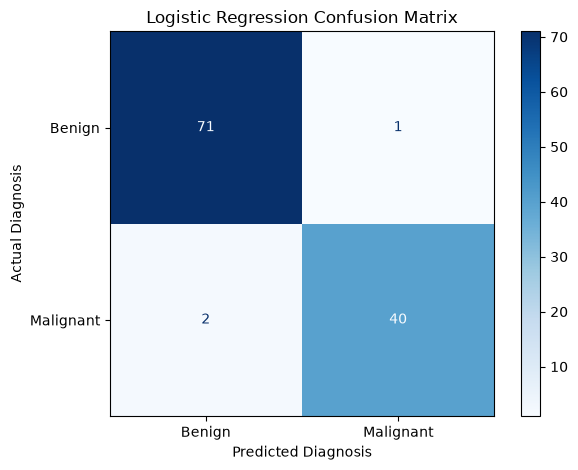

In [59]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    labels=[0, 1],
    display_labels=["Benign", "Malignant"],
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix presents correct and incorrect predictions for both diagnosis
classes. True negatives and true positives represent correctly classified benign
and malignant cases. False positives represent benign cases predicted as malignant,
while false negatives represent malignant cases predicted as benign. False negatives
are particularly important because the model failed to identify those malignant cases.

In [60]:
logistic_classification_report = classification_report(
    y_test,
    logistic_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    digits=4,
    zero_division=0
)

print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("=" * 55)
print(logistic_classification_report)

LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9726    0.9861    0.9793        72
   Malignant     0.9756    0.9524    0.9639        42

    accuracy                         0.9737       114
   macro avg     0.9741    0.9692    0.9716       114
weighted avg     0.9737    0.9737    0.9736       114



In [61]:
logistic_report_dictionary = classification_report(
    y_test,
    logistic_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

logistic_classification_report_df = (
    pd.DataFrame(logistic_report_dictionary)
    .transpose()
)

logistic_classification_report_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1-score": "{:.4f}",
    "support": "{:.0f}"
})

,precision,recall,f1-score,support
Benign,0.9726,0.9861,0.9793,72
Malignant,0.9756,0.9524,0.9639,42
accuracy,0.9737,0.9737,0.9737,1
macro avg,0.9741,0.9692,0.9716,114
weighted avg,0.9737,0.9737,0.9736,114


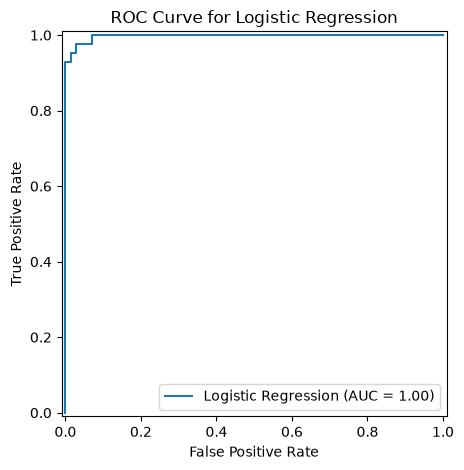

In [62]:
RocCurveDisplay.from_predictions(
    y_test,
    logistic_malignant_probabilities,
    name="Logistic Regression"
)

plt.title("ROC Curve for Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

In [63]:
model_comparison_results = pd.DataFrame({
    "ML Model Name": ["Logistic Regression"],
    "Accuracy": [logistic_accuracy],
    "AUC": [logistic_auc],
    "Precision": [logistic_precision],
    "Recall": [logistic_recall],
    "F1": [logistic_f1],
    "MCC": [logistic_mcc]
})

model_comparison_results.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433


In [64]:
logistic_observation = (
    f"Logistic Regression achieved an accuracy of "
    f"{logistic_accuracy:.4f}, an AUC score of "
    f"{logistic_auc:.4f}, a precision of "
    f"{logistic_precision:.4f}, a recall of "
    f"{logistic_recall:.4f}, an F1 score of "
    f"{logistic_f1:.4f}, and an MCC score of "
    f"{logistic_mcc:.4f}. Standardization helped the model handle "
    f"features with different numerical scales. The false-negative "
    f"count was {logistic_false_negatives}, which should be considered "
    f"when evaluating the model's ability to identify malignant cases."
)

print(logistic_observation)

Logistic Regression achieved an accuracy of 0.9737, an AUC score of 0.9974, a precision of 0.9756, a recall of 0.9524, an F1 score of 0.9639, and an MCC score of 0.9433. Standardization helped the model handle features with different numerical scales. The false-negative count was 2, which should be considered when evaluating the model's ability to identify malignant cases.


## Logistic Regression Performance Observation

Logistic Regression was trained using a pipeline containing StandardScaler and
LogisticRegression. Standardization was applied because the dataset features have
different numerical ranges.

The model achieved an accuracy of **0.9737**, an AUC score of
**0.9974**, a precision of **0.9756	**, a recall of
**0.9524**, an F1 score of **0.9639**, and an MCC score of
**0.9433**.

The AUC score describes the model's ability to separate malignant and benign
records. Recall is important in this classification problem because it measures
how many actual malignant cases were identified correctly. The confusion matrix
showed **2** malignant cases incorrectly predicted as
benign.

The overall winning model cannot be selected yet because all five models must be
evaluated using the same test dataset.

In [65]:
print("LOGISTIC REGRESSION IMPLEMENTATION SUMMARY")
print("=" * 60)
print("Model source file        : model/logistic_regression.py")
print("Model source available   :", LOGISTIC_SOURCE_PATH.exists())
print("Preprocessing            : StandardScaler")
print("Pipeline used            : Yes")
print("Training instances       :", X_train.shape[0])
print("Testing instances        :", X_test.shape[0])
print("Input features           :", X_train.shape[1])
print("Positive class           : Malignant")
print("Positive-class encoding  : 1")
print("-" * 60)
print(f"Accuracy                  : {logistic_accuracy:.4f}")
print(f"AUC                       : {logistic_auc:.4f}")
print(f"Precision                 : {logistic_precision:.4f}")
print(f"Recall                    : {logistic_recall:.4f}")
print(f"F1 Score                  : {logistic_f1:.4f}")
print(f"MCC                       : {logistic_mcc:.4f}")
print("-" * 60)
print("True Negatives           :", logistic_true_negatives)
print("False Positives          :", logistic_false_positives)
print("False Negatives          :", logistic_false_negatives)
print("True Positives           :", logistic_true_positives)
print("=" * 60)
print("Logistic Regression implementation completed successfully.")

LOGISTIC REGRESSION IMPLEMENTATION SUMMARY
Model source file        : model/logistic_regression.py
Model source available   : True
Preprocessing            : StandardScaler
Pipeline used            : Yes
Training instances       : 455
Testing instances        : 114
Input features           : 30
Positive class           : Malignant
Positive-class encoding  : 1
------------------------------------------------------------
Accuracy                  : 0.9737
AUC                       : 0.9974
Precision                 : 0.9756
Recall                    : 0.9524
F1 Score                  : 0.9639
MCC                       : 0.9433
------------------------------------------------------------
True Negatives           : 71
False Positives          : 1
False Negatives          : 2
True Positives           : 40
Logistic Regression implementation completed successfully.


# Model 2: Decision Tree Classifier

A Decision Tree Classifier predicts the target class by learning a sequence of
decision rules from the input features. Feature scaling is not required because
the model divides the data using feature-based threshold conditions rather than
distance calculations.

To reduce the possibility of overfitting, the maximum tree depth and minimum
number of samples required for splitting are controlled. The model is evaluated
using the same training and testing datasets used for Logistic Regression.

In [66]:
MODEL_DIRECTORY = Path("model")
MODEL_DIRECTORY.mkdir(exist_ok=True)

print("Model directory available:", MODEL_DIRECTORY.exists())

Model directory available: True


In [67]:
DECISION_TREE_MODEL_SOURCE = """
\"\"\"
Decision Tree Classifier model definition.

This module creates a Decision Tree Classifier for the Breast Cancer
Wisconsin Diagnostic classification problem.
\"\"\"

from sklearn.tree import DecisionTreeClassifier


def create_decision_tree_model(random_state=17):
    \"\"\"
    Create a Decision Tree classification model.

    Feature scaling is not included because a Decision Tree uses feature
    thresholds to divide the dataset and is not sensitive to differences
    in feature magnitude.

    Parameters
    ----------
    random_state : int, default=17
        Fixed random seed used for reproducibility.

    Returns
    -------
    sklearn.tree.DecisionTreeClassifier
        Configured Decision Tree classification model.
    \"\"\"

    decision_tree_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=random_state
    )

    return decision_tree_model
"""

DECISION_TREE_SOURCE_PATH = (
    MODEL_DIRECTORY / "decision_tree.py"
)

DECISION_TREE_SOURCE_PATH.write_text(
    DECISION_TREE_MODEL_SOURCE,
    encoding="utf-8"
)

print("Decision Tree source file created successfully.")
print("File path:", DECISION_TREE_SOURCE_PATH)
print("File exists:", DECISION_TREE_SOURCE_PATH.exists())

Decision Tree source file created successfully.
File path: model\decision_tree.py
File exists: True


In [68]:
from model.decision_tree import create_decision_tree_model

print("Decision Tree model function imported successfully.")

Decision Tree model function imported successfully.


In [69]:
decision_tree_model = create_decision_tree_model(
    random_state=17
)

print("Decision Tree model created successfully.")
print(decision_tree_model)

Decision Tree model created successfully.
DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=4,
                       random_state=17)


In [70]:
print("Decision Tree configuration:")
print("Criterion         :", decision_tree_model.criterion)
print("Maximum depth     :", decision_tree_model.max_depth)
print("Minimum split size:", decision_tree_model.min_samples_split)
print("Minimum leaf size :", decision_tree_model.min_samples_leaf)
print("Random state      :", decision_tree_model.random_state)

Decision Tree configuration:
Criterion         : gini
Maximum depth     : 5
Minimum split size: 4
Minimum leaf size : 2
Random state      : 17


In [71]:
decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree model trained")

Decision Tree model trained


In [72]:
print("Number of input features:", decision_tree_model.n_features_in_)
print("Classes learned          :", decision_tree_model.classes_)
print("Actual tree depth        :", decision_tree_model.get_depth())
print("Number of leaf nodes     :", decision_tree_model.get_n_leaves())

Number of input features: 30
Classes learned          : [0 1]
Actual tree depth        : 5
Number of leaf nodes     : 13


In [73]:
decision_tree_predictions = (
    decision_tree_model.predict(X_test)
)

print("Decision Tree predictions generated successfully.")
print("Number of predictions:", len(decision_tree_predictions))
print("Unique predicted classes:", set(decision_tree_predictions))

Decision Tree predictions generated successfully.
Number of predictions: 114
Unique predicted classes: {np.int64(0), np.int64(1)}


In [74]:
decision_tree_probability_matrix = (
    decision_tree_model.predict_proba(X_test)
)

print(
    "Probability matrix shape:",
    decision_tree_probability_matrix.shape
)

print("First five probability rows:")
print(decision_tree_probability_matrix[:5])

Probability matrix shape: (114, 2)
First five probability rows:
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


In [75]:
decision_tree_malignant_probabilities = (
    decision_tree_probability_matrix[:, 1]
)

print(
    "Number of malignant probability scores:",
    len(decision_tree_malignant_probabilities)
)

print("First five malignant probabilities:")
print(decision_tree_malignant_probabilities[:5])

Number of malignant probability scores: 114
First five malignant probabilities:
[1. 0. 1. 0. 1.]


In [76]:
import pandas as pd

diagnosis_name_mapping = {
    0: "Benign",
    1: "Malignant"
}

decision_tree_prediction_table = pd.DataFrame({
    "Actual Value": y_test.to_numpy(),
    "Predicted Value": decision_tree_predictions,
    "Malignant Probability": decision_tree_malignant_probabilities
})

decision_tree_prediction_table["Actual Diagnosis"] = (
    decision_tree_prediction_table["Actual Value"]
    .map(diagnosis_name_mapping)
)

decision_tree_prediction_table["Predicted Diagnosis"] = (
    decision_tree_prediction_table["Predicted Value"]
    .map(diagnosis_name_mapping)
)

decision_tree_prediction_table = decision_tree_prediction_table[
    [
        "Actual Value",
        "Predicted Value",
        "Actual Diagnosis",
        "Predicted Diagnosis",
        "Malignant Probability"
    ]
]

decision_tree_prediction_table.head(10).style.format({
    "Malignant Probability": "{:.4f}"
})

,Actual Value,Predicted Value,Actual Diagnosis,Predicted Diagnosis,Malignant Probability
0,1,1,Malignant,Malignant,1.0000
1,0,0,Benign,Benign,0.0000
2,1,1,Malignant,Malignant,1.0000
3,0,0,Benign,Benign,0.0000
4,1,1,Malignant,Malignant,1.0000
5,0,0,Benign,Benign,0.0000
6,0,0,Benign,Benign,0.0000
7,0,0,Benign,Benign,0.0526
8,1,1,Malignant,Malignant,1.0000
9,1,1,Malignant,Malignant,1.0000


In [77]:
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

decision_tree_auc = roc_auc_score(
    y_test,
    decision_tree_malignant_probabilities
)

decision_tree_precision = precision_score(
    y_test,
    decision_tree_predictions,
    pos_label=1,
    zero_division=0
)

decision_tree_recall = recall_score(
    y_test,
    decision_tree_predictions,
    pos_label=1,
    zero_division=0
)

decision_tree_f1 = f1_score(
    y_test,
    decision_tree_predictions,
    pos_label=1,
    zero_division=0
)

decision_tree_mcc = matthews_corrcoef(
    y_test,
    decision_tree_predictions
)

print("All Decision Tree metrics calculated successfully.")

All Decision Tree metrics calculated successfully.


In [78]:
print("DECISION TREE EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy  : {decision_tree_accuracy:.4f}")
print(f"AUC Score : {decision_tree_auc:.4f}")
print(f"Precision : {decision_tree_precision:.4f}")
print(f"Recall    : {decision_tree_recall:.4f}")
print(f"F1 Score  : {decision_tree_f1:.4f}")
print(f"MCC Score : {decision_tree_mcc:.4f}")
print("=" * 50)

DECISION TREE EVALUATION RESULTS
Accuracy  : 0.9386
AUC Score : 0.9107
Precision : 0.9730
Recall    : 0.8571
F1 Score  : 0.9114
MCC Score : 0.8688


In [79]:
decision_tree_metrics_df = pd.DataFrame({
    "ML Model Name": ["Decision Tree"],
    "Accuracy": [decision_tree_accuracy],
    "AUC": [decision_tree_auc],
    "Precision": [decision_tree_precision],
    "Recall": [decision_tree_recall],
    "F1": [decision_tree_f1],
    "MCC": [decision_tree_mcc]
})

decision_tree_metrics_df.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688


In [80]:
decision_tree_confusion_matrix = confusion_matrix(
    y_test,
    decision_tree_predictions,
    labels=[0, 1]
)

print("Decision Tree Confusion Matrix:")
print(decision_tree_confusion_matrix)

Decision Tree Confusion Matrix:
[[71  1]
 [ 6 36]]


In [81]:
(
    decision_tree_true_negatives,
    decision_tree_false_positives,
    decision_tree_false_negatives,
    decision_tree_true_positives
) = decision_tree_confusion_matrix.ravel()

print("True Negatives :", decision_tree_true_negatives)
print("False Positives:", decision_tree_false_positives)
print("False Negatives:", decision_tree_false_negatives)
print("True Positives :", decision_tree_true_positives)

True Negatives : 71
False Positives: 1
False Negatives: 6
True Positives : 36


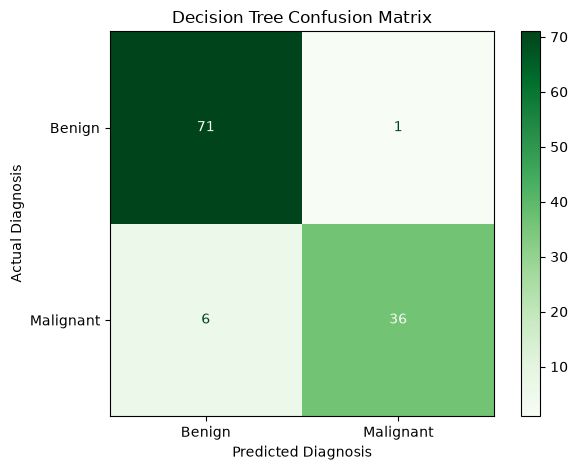

In [82]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_predictions,
    labels=[0, 1],
    display_labels=["Benign", "Malignant"],
    cmap="Greens",
    values_format="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()

### Decision Tree Confusion Matrix Interpretation

The confusion matrix shows how the Decision Tree classified benign and malignant
test records. False negatives represent malignant cases that were incorrectly
classified as benign, while false positives represent benign cases that were
incorrectly classified as malignant. These errors should be considered along with
accuracy when evaluating the model.

In [83]:
decision_tree_classification_report = classification_report(
    y_test,
    decision_tree_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    digits=4,
    zero_division=0
)

print("DECISION TREE CLASSIFICATION REPORT")
print("=" * 55)
print(decision_tree_classification_report)

DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9221    0.9861    0.9530        72
   Malignant     0.9730    0.8571    0.9114        42

    accuracy                         0.9386       114
   macro avg     0.9475    0.9216    0.9322       114
weighted avg     0.9408    0.9386    0.9377       114



In [84]:
decision_tree_report_dictionary = classification_report(
    y_test,
    decision_tree_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

decision_tree_classification_report_df = (
    pd.DataFrame(decision_tree_report_dictionary)
    .transpose()
)

decision_tree_classification_report_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1-score": "{:.4f}",
    "support": "{:.0f}"
})

,precision,recall,f1-score,support
Benign,0.9221,0.9861,0.9530,72
Malignant,0.9730,0.8571,0.9114,42
accuracy,0.9386,0.9386,0.9386,1
macro avg,0.9475,0.9216,0.9322,114
weighted avg,0.9408,0.9386,0.9377,114


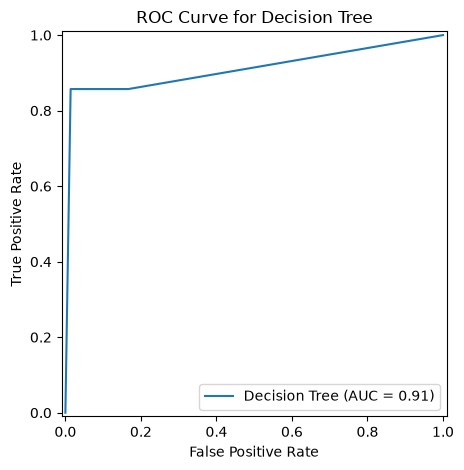

In [85]:
RocCurveDisplay.from_predictions(
    y_test,
    decision_tree_malignant_probabilities,
    name="Decision Tree"
)

plt.title("ROC Curve for Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

In [86]:
decision_tree_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree_model.feature_importances_
})

decision_tree_feature_importance = (
    decision_tree_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

decision_tree_feature_importance.head(10).style.format({
    "Importance": "{:.4f}"
})

,Feature,Importance
0,radius_worst,0.7248
1,concave_points_worst,0.0934
2,texture_worst,0.0600
3,fractal_dimension_se,0.0360
4,texture_mean,0.0345
5,concave_points_mean,0.0241
6,texture_se,0.0097
7,radius_se,0.0088
8,smoothness_mean,0.0048
9,area_worst,0.0039


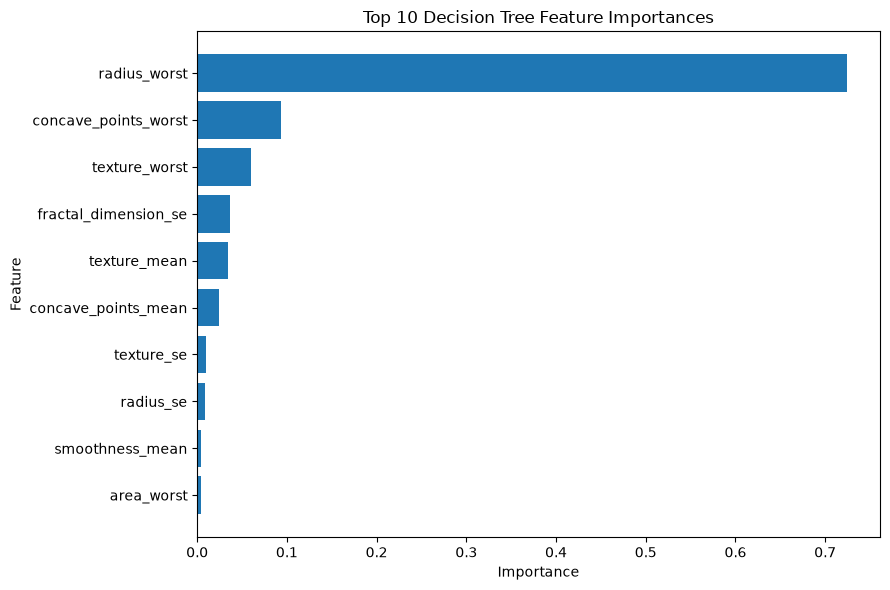

In [87]:
top_decision_tree_features = (
    decision_tree_feature_importance.head(10)
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_decision_tree_features["Feature"][::-1],
    top_decision_tree_features["Importance"][::-1]
)

plt.title("Top 10 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [88]:
assert len(decision_tree_predictions) == len(y_test), (
    "The number of Decision Tree predictions is incorrect."
)

assert len(decision_tree_malignant_probabilities) == len(y_test), (
    "The number of Decision Tree probability scores is incorrect."
)

assert set(decision_tree_predictions).issubset({0, 1}), (
    "The Decision Tree generated an unexpected class."
)

assert (
    (decision_tree_malignant_probabilities >= 0).all()
    and
    (decision_tree_malignant_probabilities <= 1).all()
), "Decision Tree probability scores must be between 0 and 1."

assert 0 <= decision_tree_accuracy <= 1, (
    "Accuracy must be between 0 and 1."
)

assert 0 <= decision_tree_auc <= 1, (
    "AUC must be between 0 and 1."
)

assert 0 <= decision_tree_precision <= 1, (
    "Precision must be between 0 and 1."
)

assert 0 <= decision_tree_recall <= 1, (
    "Recall must be between 0 and 1."
)

assert 0 <= decision_tree_f1 <= 1, (
    "F1 score must be between 0 and 1."
)

assert -1 <= decision_tree_mcc <= 1, (
    "MCC must be between -1 and 1."
)

assert decision_tree_confusion_matrix.sum() == len(y_test), (
    "Confusion matrix total is incorrect."
)

assert DECISION_TREE_SOURCE_PATH.exists(), (
    "The Decision Tree .py source file was not found."
)

print("All Decision Tree validation checks passed successfully.")

All Decision Tree validation checks passed successfully.


In [89]:
model_comparison_results

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.973684,0.997354,0.97561,0.952381,0.963855,0.94334


In [90]:
model_comparison_results = pd.concat(
    [
        model_comparison_results,
        decision_tree_metrics_df
    ],
    ignore_index=True
)

model_comparison_results.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688


In [91]:
model_comparison_results = (
    model_comparison_results
    .drop_duplicates(
        subset=["ML Model Name"],
        keep="last"
    )
    .reset_index(drop=True)
)

model_comparison_results.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688


In [92]:
decision_tree_observation = (
    f"The Decision Tree achieved an accuracy of "
    f"{decision_tree_accuracy:.4f}, an AUC score of "
    f"{decision_tree_auc:.4f}, a precision of "
    f"{decision_tree_precision:.4f}, a recall of "
    f"{decision_tree_recall:.4f}, an F1 score of "
    f"{decision_tree_f1:.4f}, and an MCC score of "
    f"{decision_tree_mcc:.4f}. The trained tree had a depth of "
    f"{decision_tree_model.get_depth()} and "
    f"{decision_tree_model.get_n_leaves()} leaf nodes. "
    f"The false-negative count was "
    f"{decision_tree_false_negatives}."
)

print(decision_tree_observation)

The Decision Tree achieved an accuracy of 0.9386, an AUC score of 0.9107, a precision of 0.9730, a recall of 0.8571, an F1 score of 0.9114, and an MCC score of 0.8688. The trained tree had a depth of 5 and 13 leaf nodes. The false-negative count was 6.


## Decision Tree Performance Observation

The Decision Tree was trained directly on the original numerical features because
tree-based models do not require feature scaling. Tree complexity was controlled
using maximum depth, minimum split size, and minimum leaf size.

The model achieved an accuracy of **0.9386**, an AUC score of
**0.9107**, a precision of **0.9730**, a recall of
**0.8571**, an F1 score of **0.9114**, and an MCC score of
**0.8688**.

The trained tree had a depth of **5** and contained
**13** leaf nodes. The confusion matrix showed
**6** malignant cases incorrectly classified as benign.
The depth restriction helps reduce overfitting, although the Decision Tree performance must be compared with the remaining models before choosing an overall
winner.

In [93]:
print("DECISION TREE IMPLEMENTATION SUMMARY")
print("=" * 60)
print("Model source file        : model/decision_tree.py")
print("Model source available   :", DECISION_TREE_SOURCE_PATH.exists())
print("Feature scaling          : No")
print("Criterion                :", decision_tree_model.criterion)
print("Configured max depth     :", decision_tree_model.max_depth)
print("Actual tree depth        :", decision_tree_model.get_depth())
print("Number of leaf nodes     :", decision_tree_model.get_n_leaves())
print("Training instances       :", X_train.shape[0])
print("Testing instances        :", X_test.shape[0])
print("Input features           :", X_train.shape[1])
print("Positive class           : Malignant")
print("Positive-class encoding  : 1")
print("-" * 60)
print(f"Accuracy                  : {decision_tree_accuracy:.4f}")
print(f"AUC                       : {decision_tree_auc:.4f}")
print(f"Precision                 : {decision_tree_precision:.4f}")
print(f"Recall                    : {decision_tree_recall:.4f}")
print(f"F1 Score                  : {decision_tree_f1:.4f}")
print(f"MCC                       : {decision_tree_mcc:.4f}")
print("-" * 60)
print("True Negatives           :", decision_tree_true_negatives)
print("False Positives          :", decision_tree_false_positives)
print("False Negatives          :", decision_tree_false_negatives)
print("True Positives           :", decision_tree_true_positives)
print("=" * 60)
print("Decision Tree implementation completed successfully.")

DECISION TREE IMPLEMENTATION SUMMARY
Model source file        : model/decision_tree.py
Model source available   : True
Feature scaling          : No
Criterion                : gini
Configured max depth     : 5
Actual tree depth        : 5
Number of leaf nodes     : 13
Training instances       : 455
Testing instances        : 114
Input features           : 30
Positive class           : Malignant
Positive-class encoding  : 1
------------------------------------------------------------
Accuracy                  : 0.9386
AUC                       : 0.9107
Precision                 : 0.9730
Recall                    : 0.8571
F1 Score                  : 0.9114
MCC                       : 0.8688
------------------------------------------------------------
True Negatives           : 71
False Positives          : 1
False Negatives          : 6
True Positives           : 36
Decision Tree implementation completed successfully.


# Model 3: k-Nearest Neighbors Classifier

The k-Nearest Neighbors classifier predicts the diagnosis of a record based on
the classes of its nearest training observations. Since kNN uses distance
calculations, StandardScaler is applied to prevent features with larger numerical
values from dominating the distance measurement.

The scaler and classifier are combined in a pipeline so that scaling is learned
only from the training data, thereby preventing data leakage.

In [94]:
MODEL_DIRECTORY = Path("model")
MODEL_DIRECTORY.mkdir(exist_ok=True)

print("Model directory available:", MODEL_DIRECTORY.exists())

Model directory available: True


In [95]:
KNN_MODEL_SOURCE = """
\"\"\"
k-Nearest Neighbors Classifier model definition.

This module creates a preprocessing and classification pipeline for the
Breast Cancer Wisconsin Diagnostic dataset.
\"\"\"

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def create_knn_model(number_of_neighbors=5):
    \"\"\"
    Create a k-Nearest Neighbors classification pipeline.

    StandardScaler is included because kNN calculates distances between
    observations and is therefore sensitive to differences in feature scale.

    Parameters
    ----------
    number_of_neighbors : int, default=5
        Number of nearest training observations used for classification.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline containing StandardScaler and KNeighborsClassifier.
    \"\"\"

    knn_pipeline = Pipeline(
        steps=[
            (
                "feature_scaling",
                StandardScaler()
            ),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=number_of_neighbors,
                    weights="uniform",
                    metric="minkowski",
                    p=2
                )
            )
        ]
    )

    return knn_pipeline
"""

KNN_SOURCE_PATH = MODEL_DIRECTORY / "knn.py"

KNN_SOURCE_PATH.write_text(
    KNN_MODEL_SOURCE,
    encoding="utf-8"
)

print("kNN source file created successfully.")
print("File path:", KNN_SOURCE_PATH)
print("File exists:", KNN_SOURCE_PATH.exists())

kNN source file created successfully.
File path: model\knn.py
File exists: True


In [96]:
from model.knn import create_knn_model

print("kNN model function imported ")

kNN model function imported 


In [97]:
knn_model = create_knn_model(
    number_of_neighbors=5
)

print("kNN pipeline created successfully.")
print(knn_model)

kNN pipeline created successfully.
Pipeline(steps=[('feature_scaling', StandardScaler()),
                ('classifier', KNeighborsClassifier())])


In [98]:
knn_classifier = knn_model.named_steps["classifier"]

print("kNN model configuration")
print("=" * 45)
print("Number of neighbors:", knn_classifier.n_neighbors)
print("Weights            :", knn_classifier.weights)
print("Distance metric    :", knn_classifier.metric)
print("Minkowski p value  :", knn_classifier.p)

kNN model configuration
Number of neighbors: 5
Weights            : uniform
Distance metric    : minkowski
Minkowski p value  : 2


In [99]:
knn_model.fit(
    X_train,
    y_train
)

print("kNN model trained successfully.")

kNN model trained successfully.


In [100]:
print("Number of input features:", knn_model.n_features_in_)

print(
    "Classes learned:",
    knn_model.named_steps["classifier"].classes_
)

print(
    "Training records retained by kNN:",
    knn_model.named_steps["classifier"].n_samples_fit_
)

Number of input features: 30
Classes learned: [0 1]
Training records retained by kNN: 455


In [101]:
knn_predictions = knn_model.predict(X_test)

print("kNN predictions generated successfully.")
print("Number of predictions:", len(knn_predictions))
print("Unique predicted classes:", set(knn_predictions))

kNN predictions generated successfully.
Number of predictions: 114
Unique predicted classes: {np.int64(0), np.int64(1)}


In [102]:
knn_probability_matrix = knn_model.predict_proba(
    X_test
)

print("Probability matrix shape:", knn_probability_matrix.shape)
print("First five probability rows:")
print(knn_probability_matrix[:5])

Probability matrix shape: (114, 2)
First five probability rows:
[[0.2 0.8]
 [1.  0. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]]


In [103]:
knn_malignant_probabilities = (
    knn_probability_matrix[:, 1]
)

print(
    "Number of malignant probability scores:",
    len(knn_malignant_probabilities)
)

print("First five malignant probabilities:")

Number of malignant probability scores: 114
First five malignant probabilities:


In [104]:
import pandas as pd

diagnosis_name_mapping = {
    0: "Benign",
    1: "Malignant"
}

knn_prediction_table = pd.DataFrame({
    "Actual Value": y_test.to_numpy(),
    "Predicted Value": knn_predictions,
    "Malignant Probability": knn_malignant_probabilities
})

knn_prediction_table["Actual Diagnosis"] = (
    knn_prediction_table["Actual Value"]
    .map(diagnosis_name_mapping)
)

knn_prediction_table["Predicted Diagnosis"] = (
    knn_prediction_table["Predicted Value"]
    .map(diagnosis_name_mapping)
)

knn_prediction_table = knn_prediction_table[
    [
        "Actual Value",
        "Predicted Value",
        "Actual Diagnosis",
        "Predicted Diagnosis",
        "Malignant Probability"
    ]
]

knn_prediction_table.head(10).style.format({
    "Malignant Probability": "{:.4f}"
})

,Actual Value,Predicted Value,Actual Diagnosis,Predicted Diagnosis,Malignant Probability
0,1,1,Malignant,Malignant,0.8000
1,0,0,Benign,Benign,0.0000
2,1,1,Malignant,Malignant,1.0000
3,0,0,Benign,Benign,0.0000
4,1,1,Malignant,Malignant,1.0000
5,0,0,Benign,Benign,0.0000
6,0,0,Benign,Benign,0.0000
7,0,0,Benign,Benign,0.0000
8,1,1,Malignant,Malignant,1.0000
9,1,1,Malignant,Malignant,1.0000


In [105]:
knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

knn_auc = roc_auc_score(
    y_test,
    knn_malignant_probabilities
)

knn_precision = precision_score(
    y_test,
    knn_predictions,
    pos_label=1,
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    knn_predictions,
    pos_label=1,
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    knn_predictions,
    pos_label=1,
    zero_division=0
)

knn_mcc = matthews_corrcoef(
    y_test,
    knn_predictions
)

print("All kNN evaluation metrics calculated successfully.")

All kNN evaluation metrics calculated successfully.


In [106]:
print("kNN EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"AUC Score : {knn_auc:.4f}")
print(f"Precision : {knn_precision:.4f}")
print(f"Recall    : {knn_recall:.4f}")
print(f"F1 Score  : {knn_f1:.4f}")
print(f"MCC Score : {knn_mcc:.4f}")
print("=" * 50)

kNN EVALUATION RESULTS
Accuracy  : 0.9737
AUC Score : 0.9714
Precision : 1.0000
Recall    : 0.9286
F1 Score  : 0.9630
MCC Score : 0.9442


In [107]:
knn_metrics_df = pd.DataFrame({
    "ML Model Name": ["kNN"],
    "Accuracy": [knn_accuracy],
    "AUC": [knn_auc],
    "Precision": [knn_precision],
    "Recall": [knn_recall],
    "F1": [knn_f1],
    "MCC": [knn_mcc]
})

knn_metrics_df.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442


In [108]:
knn_confusion_matrix = confusion_matrix(
    y_test,
    knn_predictions,
    labels=[0, 1]
)

print("kNN Confusion Matrix:")
print(knn_confusion_matrix)

kNN Confusion Matrix:
[[72  0]
 [ 3 39]]


In [109]:
(
    knn_true_negatives,
    knn_false_positives,
    knn_false_negatives,
    knn_true_positives
) = knn_confusion_matrix.ravel()

print("True Negatives :", knn_true_negatives)
print("False Positives:", knn_false_positives)
print("False Negatives:", knn_false_negatives)
print("True Positives :", knn_true_positives)

True Negatives : 72
False Positives: 0
False Negatives: 3
True Positives : 39


In [110]:
knn_confusion_total = (
    knn_true_negatives
    + knn_false_positives
    + knn_false_negatives
    + knn_true_positives
)

print(
    "Records represented in confusion matrix:",
    knn_confusion_total
)

print("Total testing records:", len(y_test))

assert knn_confusion_total == len(y_test), (
    "The kNN confusion matrix does not contain all test records."
)

print("kNN confusion matrix validation passed.")

Records represented in confusion matrix: 114
Total testing records: 114
kNN confusion matrix validation passed.


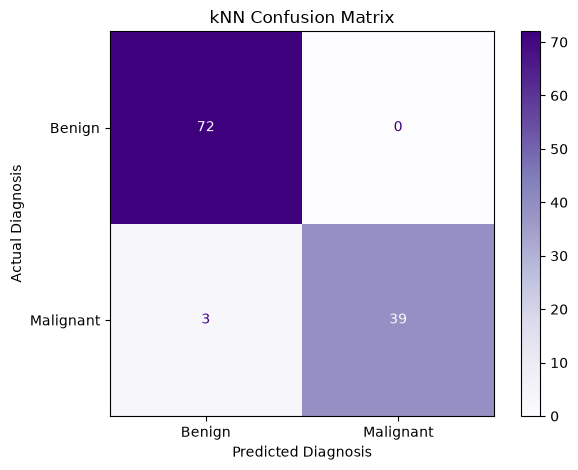

In [111]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    labels=[0, 1],
    display_labels=["Benign", "Malignant"],
    cmap="Purples",
    values_format="d"
)

plt.title("kNN Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()

### kNN Confusion Matrix Interpretation

The confusion matrix shows the number of correctly and incorrectly classified
benign and malignant records. False negatives represent malignant records that
were incorrectly predicted as benign. The false-negative count should be considered
along with accuracy, recall, F1 score, and MCC when evaluating the model.

In [112]:
knn_classification_report = classification_report(
    y_test,
    knn_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    digits=4,
    zero_division=0
)

print("kNN CLASSIFICATION REPORT")
print("=" * 55)
print(knn_classification_report)

kNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9600    1.0000    0.9796        72
   Malignant     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



In [113]:
knn_classification_report = classification_report(
    y_test,
    knn_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    digits=4,
    zero_division=0
)

print("kNN CLASSIFICATION REPORT")
print("=" * 55)
print(knn_classification_report)

kNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9600    1.0000    0.9796        72
   Malignant     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



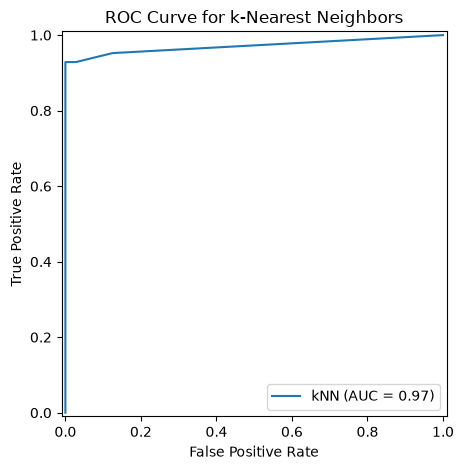

In [114]:
RocCurveDisplay.from_predictions(
    y_test,
    knn_malignant_probabilities,
    name="kNN"
)

plt.title("ROC Curve for k-Nearest Neighbors")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

In [115]:
model_comparison_results

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.973684,0.997354,0.975610,0.952381,0.963855,0.943340
1,Decision Tree,0.938596,0.910714,0.972973,0.857143,0.911392,0.868766


In [116]:
model_comparison_results = pd.concat(
    [
        model_comparison_results,
        knn_metrics_df
    ],
    ignore_index=True
)

model_comparison_results = (
    model_comparison_results
    .drop_duplicates(
        subset=["ML Model Name"],
        keep="last"
    )
    .reset_index(drop=True)
)

model_comparison_results.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688
2,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442


In [117]:
knn_observation = (
    f"The kNN classifier used five nearest neighbors and standardized "
    f"input features. The model achieved an accuracy of "
    f"{knn_accuracy:.4f}, an AUC score of {knn_auc:.4f}, "
    f"a precision of {knn_precision:.4f}, a recall of "
    f"{knn_recall:.4f}, an F1 score of {knn_f1:.4f}, "
    f"and an MCC score of {knn_mcc:.4f}. The confusion matrix "
    f"contained {knn_false_negatives} false-negative malignant cases."
)

print(knn_observation)

The kNN classifier used five nearest neighbors and standardized input features. The model achieved an accuracy of 0.9737, an AUC score of 0.9714, a precision of 1.0000, a recall of 0.9286, an F1 score of 0.9630, and an MCC score of 0.9442. The confusion matrix contained 3 false-negative malignant cases.


## kNN Performance Observation

The k-Nearest Neighbors model was implemented using five nearest neighbors.
StandardScaler was included in the pipeline because kNN calculates distances
between observations and is sensitive to differences in feature scale.

The model achieved an accuracy of **0.9737**, an AUC score of
**0.9714**, a precision of **1.0000**, a recall of
**0.9286**, an F1 score of **0.9630**, and an MCC score of
**0.9442**.

The confusion matrix showed **3** malignant cases
incorrectly classified as benign. The performance indicates how effectively
neighboring standardized observations can distinguish between benign and
malignant cases. The final model winner will be determined only after evaluating
all the required classifiers.

In [118]:
print("kNN IMPLEMENTATION SUMMARY")
print("=" * 60)
print("Model source file        : model/knn.py")
print("Model source available   :", KNN_SOURCE_PATH.exists())
print("Feature scaling          : Yes")
print("Scaling method           : StandardScaler")
print("Number of neighbors      :", knn_classifier.n_neighbors)
print("Neighbor weights         :", knn_classifier.weights)
print("Distance metric          : Euclidean")
print("Training instances       :", X_train.shape[0])
print("Testing instances        :", X_test.shape[0])
print("Input features           :", X_train.shape[1])
print("Positive class           : Malignant")
print("Positive-class encoding  : 1")
print("-" * 60)
print(f"Accuracy                  : {knn_accuracy:.4f}")
print(f"AUC                       : {knn_auc:.4f}")
print(f"Precision                 : {knn_precision:.4f}")
print(f"Recall                    : {knn_recall:.4f}")
print(f"F1 Score                  : {knn_f1:.4f}")
print(f"MCC                       : {knn_mcc:.4f}")
print("-" * 60)
print("True Negatives           :", knn_true_negatives)
print("False Positives          :", knn_false_positives)
print("False Negatives          :", knn_false_negatives)
print("True Positives           :", knn_true_positives)
print("=" * 60)
print("kNN implementation completed successfully.")

kNN IMPLEMENTATION SUMMARY
Model source file        : model/knn.py
Model source available   : True
Feature scaling          : Yes
Scaling method           : StandardScaler
Number of neighbors      : 5
Neighbor weights         : uniform
Distance metric          : Euclidean
Training instances       : 455
Testing instances        : 114
Input features           : 30
Positive class           : Malignant
Positive-class encoding  : 1
------------------------------------------------------------
Accuracy                  : 0.9737
AUC                       : 0.9714
Precision                 : 1.0000
Recall                    : 0.9286
F1 Score                  : 0.9630
MCC                       : 0.9442
------------------------------------------------------------
True Negatives           : 72
False Positives          : 0
False Negatives          : 3
True Positives           : 39
kNN implementation completed successfully.


# Model 4: Gaussian Naive Bayes Classifier

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes'
theorem. The model assumes that input features are conditionally independent for
a given class and that each continuous feature approximately follows a Gaussian
distribution.

Gaussian Naive Bayes is suitable for this dataset because all 30 input features
are continuous numerical measurements. The same training and testing datasets
used for the previous models are used to ensure a fair comparison.

In [119]:
from pathlib import Path

MODEL_DIRECTORY = Path("model")
MODEL_DIRECTORY.mkdir(exist_ok=True)

print("Model directory available:", MODEL_DIRECTORY.exists())

Model directory available: True


In [120]:
NAIVE_BAYES_MODEL_SOURCE = """
\"\"\"
Gaussian Naive Bayes model definition.

This module creates a Gaussian Naive Bayes classifier for the Breast Cancer
Wisconsin Diagnostic classification problem.
\"\"\"

from sklearn.naive_bayes import GaussianNB


def create_naive_bayes_model():
    \"\"\"
    Create a Gaussian Naive Bayes classification model.

    Gaussian Naive Bayes is used because the input features are continuous
    numerical measurements. Feature scaling is not mandatory for this model
    because GaussianNB estimates a mean and variance for each feature within
    each target class.

    Returns
    -------
    sklearn.naive_bayes.GaussianNB
        Configured Gaussian Naive Bayes classifier.
    \"\"\"

    naive_bayes_model = GaussianNB(
        var_smoothing=1e-9
    )

    return naive_bayes_model
"""

NAIVE_BAYES_SOURCE_PATH = (
    MODEL_DIRECTORY / "naive_bayes.py"
)

NAIVE_BAYES_SOURCE_PATH.write_text(
    NAIVE_BAYES_MODEL_SOURCE,
    encoding="utf-8"
)

print("Naive Bayes source file created successfully.")
print("File path:", NAIVE_BAYES_SOURCE_PATH)
print("File exists:", NAIVE_BAYES_SOURCE_PATH.exists())

Naive Bayes source file created successfully.
File path: model\naive_bayes.py
File exists: True


In [121]:
from model.naive_bayes import create_naive_bayes_model

print("Gaussian Naive Bayes model function imported successfully.")


Gaussian Naive Bayes model function imported successfully.


In [122]:
import importlib
import model.naive_bayes

importlib.reload(model.naive_bayes)

from model.naive_bayes import create_naive_bayes_model

naive_bayes_model = create_naive_bayes_model()

print("Gaussian Naive Bayes model created successfully.")
print(naive_bayes_model)


Gaussian Naive Bayes model created successfully.
GaussianNB()


In [123]:
print("Gaussian Naive Bayes configuration")
print("=" * 45)
print("Variance smoothing:", naive_bayes_model.var_smoothing)
print("Feature scaling   : Not applied")

Gaussian Naive Bayes configuration
Variance smoothing: 1e-09
Feature scaling   : Not applied


In [124]:
naive_bayes_model.fit(
    X_train,
    y_train
)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [125]:
naive_bayes_predictions = naive_bayes_model.predict(X_test)

naive_bayes_probability_matrix = (
    naive_bayes_model.predict_proba(X_test)
)

naive_bayes_malignant_probabilities = (
    naive_bayes_probability_matrix[:, 1]
)

print("Predictions generated:", len(naive_bayes_predictions))
print(
    "Probability scores generated:",
    len(naive_bayes_malignant_probabilities)
)

Predictions generated: 114
Probability scores generated: 114


In [126]:
naive_bayes_probability_matrix = (
    naive_bayes_model.predict_proba(X_test)
)

print(
    "Probability matrix shape:",
    naive_bayes_probability_matrix.shape
)

print("First five probability rows:")

Probability matrix shape: (114, 2)
First five probability rows:


In [127]:
import numpy as np

probability_row_sums = (
    naive_bayes_probability_matrix.sum(axis=1)
)

print("First five probability row sums:")
print(probability_row_sums[:5])

assert np.allclose(
    probability_row_sums,
    1.0
), "The Naive Bayes probabilities do not sum to 1."

print("Probability matrix validation passed.")

First five probability row sums:
[1. 1. 1. 1. 1.]
Probability matrix validation passed.


In [128]:
import pandas as pd

diagnosis_name_mapping = {
    0: "Benign",
    1: "Malignant"
}

naive_bayes_prediction_table = pd.DataFrame({
    "Actual Value": y_test.to_numpy(),
    "Predicted Value": naive_bayes_predictions,
    "Malignant Probability": naive_bayes_malignant_probabilities
})

naive_bayes_prediction_table["Actual Diagnosis"] = (
    naive_bayes_prediction_table["Actual Value"]
    .map(diagnosis_name_mapping)
)

naive_bayes_prediction_table["Predicted Diagnosis"] = (
    naive_bayes_prediction_table["Predicted Value"]
    .map(diagnosis_name_mapping)
)

naive_bayes_prediction_table = naive_bayes_prediction_table[
    [
        "Actual Value",
        "Predicted Value",
        "Actual Diagnosis",
        "Predicted Diagnosis",
        "Malignant Probability"
    ]
]

naive_bayes_prediction_table.head(10).style.format({
    "Malignant Probability": "{:.4f}"
})

,Actual Value,Predicted Value,Actual Diagnosis,Predicted Diagnosis,Malignant Probability
0,1,1,Malignant,Malignant,1.0000
1,0,0,Benign,Benign,0.0000
2,1,1,Malignant,Malignant,1.0000
3,0,0,Benign,Benign,0.0000
4,1,1,Malignant,Malignant,1.0000
5,0,0,Benign,Benign,0.0000
6,0,0,Benign,Benign,0.0000
7,0,0,Benign,Benign,0.0000
8,1,1,Malignant,Malignant,1.0000
9,1,1,Malignant,Malignant,1.0000


In [129]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [130]:
naive_bayes_accuracy = accuracy_score(
    y_test,
    naive_bayes_predictions
)

naive_bayes_auc = roc_auc_score(
    y_test,
    naive_bayes_malignant_probabilities
)

naive_bayes_precision = precision_score(
    y_test,
    naive_bayes_predictions,
    pos_label=1,
    zero_division=0
)

naive_bayes_recall = recall_score(
    y_test,
    naive_bayes_predictions,
    pos_label=1,
    zero_division=0
)

naive_bayes_f1 = f1_score(
    y_test,
    naive_bayes_predictions,
    pos_label=1,
    zero_division=0
)

naive_bayes_mcc = matthews_corrcoef(
    y_test,
    naive_bayes_predictions
)

print("All Gaussian Naive Bayes metrics calculated successfully.")

All Gaussian Naive Bayes metrics calculated successfully.


In [131]:
print("GAUSSIAN NAIVE BAYES EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy  : {naive_bayes_accuracy:.4f}")
print(f"AUC Score : {naive_bayes_auc:.4f}")
print(f"Precision : {naive_bayes_precision:.4f}")
print(f"Recall    : {naive_bayes_recall:.4f}")
print(f"F1 Score  : {naive_bayes_f1:.4f}")
print(f"MCC Score : {naive_bayes_mcc:.4f}")
print("=" * 50)

GAUSSIAN NAIVE BAYES EVALUATION RESULTS
Accuracy  : 0.9386
AUC Score : 0.9897
Precision : 0.9487
Recall    : 0.8810
F1 Score  : 0.9136
MCC Score : 0.8675


In [132]:
naive_bayes_metrics_df = pd.DataFrame({
    "ML Model Name": ["Naive Bayes"],
    "Accuracy": [naive_bayes_accuracy],
    "AUC": [naive_bayes_auc],
    "Precision": [naive_bayes_precision],
    "Recall": [naive_bayes_recall],
    "F1": [naive_bayes_f1],
    "MCC": [naive_bayes_mcc]
})

naive_bayes_metrics_df.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Naive Bayes,0.9386,0.9897,0.9487,0.8810,0.9136,0.8675


In [133]:
naive_bayes_confusion_matrix = confusion_matrix(
    y_test,
    naive_bayes_predictions,
    labels=[0, 1]
)

print("Gaussian Naive Bayes Confusion Matrix:")
print(naive_bayes_confusion_matrix)

Gaussian Naive Bayes Confusion Matrix:
[[70  2]
 [ 5 37]]


In [134]:
(
    naive_bayes_true_negatives,
    naive_bayes_false_positives,
    naive_bayes_false_negatives,
    naive_bayes_true_positives
) = naive_bayes_confusion_matrix.ravel()

print("True Negatives :", naive_bayes_true_negatives)
print("False Positives:", naive_bayes_false_positives)
print("False Negatives:", naive_bayes_false_negatives)
print("True Positives :", naive_bayes_true_positives)

True Negatives : 70
False Positives: 2
False Negatives: 5
True Positives : 37


In [135]:
naive_bayes_confusion_total = (
    naive_bayes_true_negatives
    + naive_bayes_false_positives
    + naive_bayes_false_negatives
    + naive_bayes_true_positives
)

print(
    "Records represented in confusion matrix:",
    naive_bayes_confusion_total
)

print("Total testing records:", len(y_test))

assert naive_bayes_confusion_total == len(y_test), (
    "The Naive Bayes confusion matrix does not include every test record."
)

print("Naive Bayes confusion matrix validation passed.")

Records represented in confusion matrix: 114
Total testing records: 114
Naive Bayes confusion matrix validation passed.


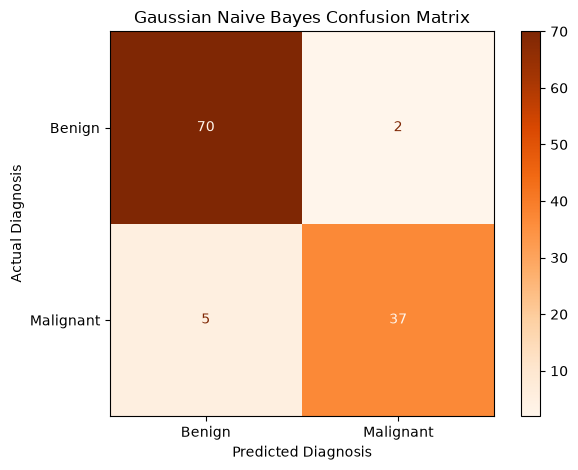

In [136]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    naive_bayes_predictions,
    labels=[0, 1],
    display_labels=["Benign", "Malignant"],
    cmap="Oranges",
    values_format="d"
)

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()

### Gaussian Naive Bayes Confusion Matrix Interpretation

The confusion matrix shows how Gaussian Naive Bayes classified the benign and
malignant test observations. False negatives represent malignant cases classified
as benign, while false positives represent benign cases classified as malignant.
The false-negative count should be considered along with recall and F1 score when
evaluating the model.

In [137]:
naive_bayes_classification_report = classification_report(
    y_test,
    naive_bayes_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    digits=4,
    zero_division=0
)

print("GAUSSIAN NAIVE BAYES CLASSIFICATION REPORT")
print("=" * 55)
print(naive_bayes_classification_report)

GAUSSIAN NAIVE BAYES CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9333    0.9722    0.9524        72
   Malignant     0.9487    0.8810    0.9136        42

    accuracy                         0.9386       114
   macro avg     0.9410    0.9266    0.9330       114
weighted avg     0.9390    0.9386    0.9381       114



In [138]:
naive_bayes_report_dictionary = classification_report(
    y_test,
    naive_bayes_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

naive_bayes_classification_report_df = (
    pd.DataFrame(naive_bayes_report_dictionary)
    .transpose()
)

naive_bayes_classification_report_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1-score": "{:.4f}",
    "support": "{:.0f}"
})

,precision,recall,f1-score,support
Benign,0.9333,0.9722,0.9524,72
Malignant,0.9487,0.8810,0.9136,42
accuracy,0.9386,0.9386,0.9386,1
macro avg,0.9410,0.9266,0.9330,114
weighted avg,0.9390,0.9386,0.9381,114


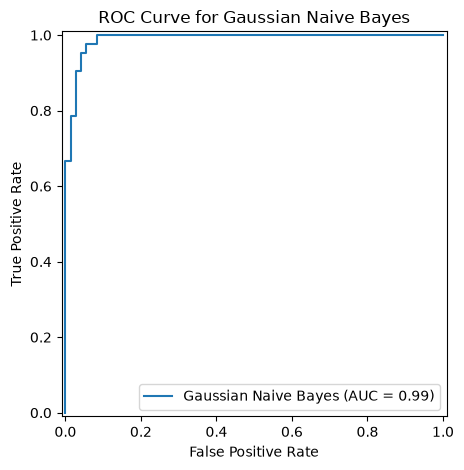

In [139]:
RocCurveDisplay.from_predictions(
    y_test,
    naive_bayes_malignant_probabilities,
    name="Gaussian Naive Bayes"
)

plt.title("ROC Curve for Gaussian Naive Bayes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

In [140]:
model_comparison_results

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.973684,0.997354,0.975610,0.952381,0.963855,0.943340
1,Decision Tree,0.938596,0.910714,0.972973,0.857143,0.911392,0.868766
2,kNN,0.973684,0.971396,1.000000,0.928571,0.962963,0.944155


In [141]:
model_comparison_results = pd.concat(
    [
        model_comparison_results,
        naive_bayes_metrics_df
    ],
    ignore_index=True
)

model_comparison_results = (
    model_comparison_results
    .drop_duplicates(
        subset=["ML Model Name"],
        keep="last"
    )
    .reset_index(drop=True)
)

model_comparison_results.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688
2,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442
3,Naive Bayes,0.9386,0.9897,0.9487,0.8810,0.9136,0.8675


In [142]:
naive_bayes_observation = (
    f"Gaussian Naive Bayes achieved an accuracy of "
    f"{naive_bayes_accuracy:.4f}, an AUC score of "
    f"{naive_bayes_auc:.4f}, a precision of "
    f"{naive_bayes_precision:.4f}, a recall of "
    f"{naive_bayes_recall:.4f}, an F1 score of "
    f"{naive_bayes_f1:.4f}, and an MCC score of "
    f"{naive_bayes_mcc:.4f}. The confusion matrix contained "
    f"{naive_bayes_false_negatives} malignant cases incorrectly "
    f"classified as benign."
)

print(naive_bayes_observation)

Gaussian Naive Bayes achieved an accuracy of 0.9386, an AUC score of 0.9897, a precision of 0.9487, a recall of 0.8810, an F1 score of 0.9136, and an MCC score of 0.8675. The confusion matrix contained 5 malignant cases incorrectly classified as benign.


## Gaussian Naive Bayes Performance Observation

Gaussian Naive Bayes was selected because all 30 input features are continuous
numerical measurements. The model estimates the probability distribution of every
feature within each diagnosis class and applies Bayes' theorem to predict the most
likely class.

The model achieved an accuracy of **0.9386**, an AUC score of
**0.9897**, a precision of **0.9487**, a recall of
**0.8810**, an F1 score of **0.9136**, and an MCC score of
**0.8675**.

The confusion matrix showed **5** malignant cases
incorrectly classified as benign. Gaussian Naive Bayes is computationally efficient,
but its conditional-independence assumption may not fully hold because several
cell-nucleus measurements are related. The overall winner will be determined after
evaluating Random Forest.

In [143]:
print("GAUSSIAN NAIVE BAYES IMPLEMENTATION SUMMARY")
print("=" * 60)
print("Model source file        : model/naive_bayes.py")
print("Model source available   :", NAIVE_BAYES_SOURCE_PATH.exists())
print("Naive Bayes type         : Gaussian")
print("Feature scaling          : No")
print("Variance smoothing       :", naive_bayes_model.var_smoothing)
print("Training instances       :", X_train.shape[0])
print("Testing instances        :", X_test.shape[0])
print("Input features           :", X_train.shape[1])
print("Positive class           : Malignant")
print("Positive-class encoding  : 1")
print("-" * 60)
print(f"Accuracy                  : {naive_bayes_accuracy:.4f}")
print(f"AUC                       : {naive_bayes_auc:.4f}")
print(f"Precision                 : {naive_bayes_precision:.4f}")
print(f"Recall                    : {naive_bayes_recall:.4f}")
print(f"F1 Score                  : {naive_bayes_f1:.4f}")
print(f"MCC                       : {naive_bayes_mcc:.4f}")
print("-" * 60)
print("True Negatives           :", naive_bayes_true_negatives)
print("False Positives          :", naive_bayes_false_positives)
print("False Negatives          :", naive_bayes_false_negatives)
print("True Positives           :", naive_bayes_true_positives)
print("=" * 60)
print("Gaussian Naive Bayes implementation completed successfully.")

GAUSSIAN NAIVE BAYES IMPLEMENTATION SUMMARY
Model source file        : model/naive_bayes.py
Model source available   : True
Naive Bayes type         : Gaussian
Feature scaling          : No
Variance smoothing       : 1e-09
Training instances       : 455
Testing instances        : 114
Input features           : 30
Positive class           : Malignant
Positive-class encoding  : 1
------------------------------------------------------------
Accuracy                  : 0.9386
AUC                       : 0.9897
Precision                 : 0.9487
Recall                    : 0.8810
F1 Score                  : 0.9136
MCC                       : 0.8675
------------------------------------------------------------
True Negatives           : 70
False Positives          : 2
False Negatives          : 5
True Positives           : 37
Gaussian Naive Bayes implementation completed successfully.


# Model 5: Random Forest Ensemble Classifier

Random Forest is an ensemble-learning algorithm that combines predictions from
multiple Decision Trees. Each tree is trained using a random sample of training
records and a random subset of features. The final class is determined by
aggregating the predictions of the individual trees.

Feature scaling is not required because Random Forest uses feature thresholds
rather than distance calculations. The same training and testing datasets used
for the previous models are used to ensure a fair comparison.

In [144]:
from pathlib import Path

MODEL_DIRECTORY = Path("model")
MODEL_DIRECTORY.mkdir(exist_ok=True)

print("Model directory available:", MODEL_DIRECTORY.exists())

Model directory available: True


In [145]:
RANDOM_FOREST_MODEL_SOURCE = """
\"\"\"
Random Forest Classifier model definition.

This module creates a Random Forest ensemble classifier for the Breast Cancer
Wisconsin Diagnostic classification problem.
\"\"\"

from sklearn.ensemble import RandomForestClassifier


def create_random_forest_model(random_state=17):
    \"\"\"
    Create a Random Forest classification model.

    Random Forest combines predictions from multiple Decision Trees.
    Feature scaling is not required because the model uses feature-based
    threshold splits rather than distance calculations.

    Parameters
    ----------
    random_state : int, default=17
        Fixed random seed used for reproducibility.

    Returns
    -------
    sklearn.ensemble.RandomForestClassifier
        Configured Random Forest classification model.
    \"\"\"

    random_forest_model = RandomForestClassifier(
        n_estimators=200,
        criterion="gini",
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        random_state=random_state,
        n_jobs=-1
    )

    return random_forest_model
"""

RANDOM_FOREST_SOURCE_PATH = (
    MODEL_DIRECTORY / "random_forest.py"
)

RANDOM_FOREST_SOURCE_PATH.write_text(
    RANDOM_FOREST_MODEL_SOURCE,
    encoding="utf-8"
)

print("Random Forest source file created successfully.")
print("File path:", RANDOM_FOREST_SOURCE_PATH)
print("File exists:", RANDOM_FOREST_SOURCE_PATH.exists())

Random Forest source file created successfully.
File path: model\random_forest.py
File exists: True


In [146]:
from model.random_forest import create_random_forest_model

print("Random Forest model function imported successfully.")

Random Forest model function imported successfully.


In [147]:
random_forest_model = create_random_forest_model(
    random_state=17
)

print("Random Forest model created successfully.")
print(random_forest_model)

Random Forest model created successfully.
RandomForestClassifier(min_samples_leaf=2, min_samples_split=4,
                       n_estimators=200, n_jobs=-1, random_state=17)


In [148]:
print("RANDOM FOREST CONFIGURATION")
print("=" * 50)
print("Number of trees       :", random_forest_model.n_estimators)
print("Split criterion       :", random_forest_model.criterion)
print("Maximum tree depth    :", random_forest_model.max_depth)
print("Minimum samples split :", random_forest_model.min_samples_split)
print("Minimum samples leaf  :", random_forest_model.min_samples_leaf)
print("Maximum features      :", random_forest_model.max_features)
print("Bootstrap sampling    :", random_forest_model.bootstrap)
print("Random state          :", random_forest_model.random_state)
print("Parallel processing   :", random_forest_model.n_jobs)
print("Feature scaling       : Not applied")

RANDOM FOREST CONFIGURATION
Number of trees       : 200
Split criterion       : gini
Maximum tree depth    : None
Minimum samples split : 4
Minimum samples leaf  : 2
Maximum features      : sqrt
Bootstrap sampling    : True
Random state          : 17
Parallel processing   : -1
Feature scaling       : Not applied


In [149]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [150]:
print("Classes learned         :", random_forest_model.classes_)
print("Number of input features:", random_forest_model.n_features_in_)
print("Number of trained trees :", random_forest_model.n_estimators)

Classes learned         : [0 1]
Number of input features: 30
Number of trained trees : 200


In [151]:
random_forest_predictions = (
    random_forest_model.predict(X_test)
)

print("Random Forest predictions generated successfully.")
print("Number of predictions:", len(random_forest_predictions))
print("Unique predicted classes:", set(random_forest_predictions))

Random Forest predictions generated successfully.
Number of predictions: 114
Unique predicted classes: {np.int64(0), np.int64(1)}


In [152]:
random_forest_probability_matrix = (
    random_forest_model.predict_proba(X_test)
)

print(
    "Probability matrix shape:",
    random_forest_probability_matrix.shape
)

print("First five probability rows:")
print(random_forest_probability_matrix[:5])

Probability matrix shape: (114, 2)
First five probability rows:
[[0.11866667 0.88133333]
 [0.861      0.139     ]
 [0.005      0.995     ]
 [0.88683333 0.11316667]
 [0.02666667 0.97333333]]


In [153]:
random_forest_malignant_probabilities = (
    random_forest_probability_matrix[:, 1]
)

print(
    "Number of malignant probability scores:",
    len(random_forest_malignant_probabilities)
)

print("First five malignant probability scores:")
print(random_forest_malignant_probabilities[:5])

Number of malignant probability scores: 114
First five malignant probability scores:
[0.88133333 0.139      0.995      0.11316667 0.97333333]


In [154]:
import numpy as np

random_forest_probability_sums = (
    random_forest_probability_matrix.sum(axis=1)
)

assert np.allclose(
    random_forest_probability_sums,
    1.0
), "Random Forest class probabilities do not sum to 1."

assert (
    (random_forest_malignant_probabilities >= 0).all()
    and
    (random_forest_malignant_probabilities <= 1).all()
), "Random Forest probability values must be between 0 and 1."

print("Random Forest probability validation passed.")

Random Forest probability validation passed.


In [155]:
import pandas as pd

diagnosis_name_mapping = {
    0: "Benign",
    1: "Malignant"
}

random_forest_prediction_table = pd.DataFrame({
    "Actual Value": y_test.to_numpy(),
    "Predicted Value": random_forest_predictions,
    "Malignant Probability": random_forest_malignant_probabilities
})

random_forest_prediction_table["Actual Diagnosis"] = (
    random_forest_prediction_table["Actual Value"]
    .map(diagnosis_name_mapping)
)

random_forest_prediction_table["Predicted Diagnosis"] = (
    random_forest_prediction_table["Predicted Value"]
    .map(diagnosis_name_mapping)
)

random_forest_prediction_table = random_forest_prediction_table[
    [
        "Actual Value",
        "Predicted Value",
        "Actual Diagnosis",
        "Predicted Diagnosis",
        "Malignant Probability"
    ]
]

random_forest_prediction_table.head(10).style.format({
    "Malignant Probability": "{:.4f}"
})

,Actual Value,Predicted Value,Actual Diagnosis,Predicted Diagnosis,Malignant Probability
0,1,1,Malignant,Malignant,0.8813
1,0,0,Benign,Benign,0.1390
2,1,1,Malignant,Malignant,0.9950
3,0,0,Benign,Benign,0.1132
4,1,1,Malignant,Malignant,0.9733
5,0,0,Benign,Benign,0.0000
6,0,0,Benign,Benign,0.0275
7,0,0,Benign,Benign,0.0643
8,1,1,Malignant,Malignant,0.9335
9,1,1,Malignant,Malignant,1.0000


In [156]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [157]:
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_auc = roc_auc_score(
    y_test,
    random_forest_malignant_probabilities
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions,
    pos_label=1,
    zero_division=0
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions,
    pos_label=1,
    zero_division=0
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions,
    pos_label=1,
    zero_division=0
)

random_forest_mcc = matthews_corrcoef(
    y_test,
    random_forest_predictions
)

print("All Random Forest evaluation metrics calculated successfully.")

All Random Forest evaluation metrics calculated successfully.


In [158]:
print("RANDOM FOREST EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy  : {random_forest_accuracy:.4f}")
print(f"AUC Score : {random_forest_auc:.4f}")
print(f"Precision : {random_forest_precision:.4f}")
print(f"Recall    : {random_forest_recall:.4f}")
print(f"F1 Score  : {random_forest_f1:.4f}")
print(f"MCC Score : {random_forest_mcc:.4f}")
print("=" * 50)

RANDOM FOREST EVALUATION RESULTS
Accuracy  : 0.9561
AUC Score : 0.9947
Precision : 0.9512
Recall    : 0.9286
F1 Score  : 0.9398
MCC Score : 0.9054


In [159]:
random_forest_metrics_df = pd.DataFrame({
    "ML Model Name": ["Random Forest"],
    "Accuracy": [random_forest_accuracy],
    "AUC": [random_forest_auc],
    "Precision": [random_forest_precision],
    "Recall": [random_forest_recall],
    "F1": [random_forest_f1],
    "MCC": [random_forest_mcc]
})

random_forest_metrics_df.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Random Forest,0.9561,0.9947,0.9512,0.9286,0.9398,0.9054


In [160]:
random_forest_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_predictions,
    labels=[0, 1]
)

print("Random Forest Confusion Matrix:")
print(random_forest_confusion_matrix)

Random Forest Confusion Matrix:
[[70  2]
 [ 3 39]]


In [161]:
(
    random_forest_true_negatives,
    random_forest_false_positives,
    random_forest_false_negatives,
    random_forest_true_positives
) = random_forest_confusion_matrix.ravel()

print("True Negatives :", random_forest_true_negatives)
print("False Positives:", random_forest_false_positives)
print("False Negatives:", random_forest_false_negatives)
print("True Positives :", random_forest_true_positives)

True Negatives : 70
False Positives: 2
False Negatives: 3
True Positives : 39


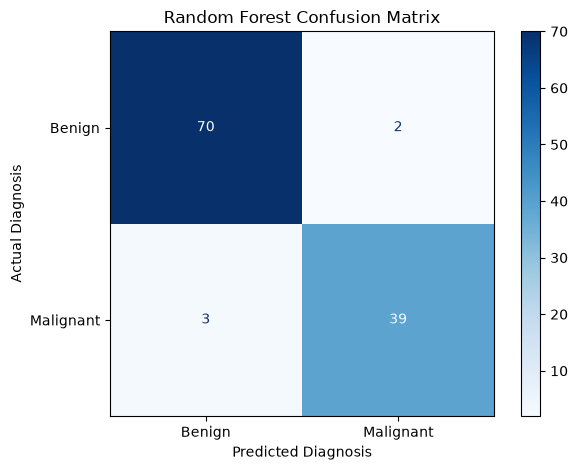

In [162]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_predictions,
    labels=[0, 1],
    display_labels=["Benign", "Malignant"],
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()

In [163]:
random_forest_classification_report = classification_report(
    y_test,
    random_forest_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    digits=4,
    zero_division=0
)

print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 55)
print(random_forest_classification_report)

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.9589    0.9722    0.9655        72
   Malignant     0.9512    0.9286    0.9398        42

    accuracy                         0.9561       114
   macro avg     0.9551    0.9504    0.9526       114
weighted avg     0.9561    0.9561    0.9560       114



In [164]:
random_forest_report_dictionary = classification_report(
    y_test,
    random_forest_predictions,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

random_forest_classification_report_df = (
    pd.DataFrame(random_forest_report_dictionary)
    .transpose()
)

random_forest_classification_report_df.style.format({
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1-score": "{:.4f}",
    "support": "{:.0f}"
})

,precision,recall,f1-score,support
Benign,0.9589,0.9722,0.9655,72
Malignant,0.9512,0.9286,0.9398,42
accuracy,0.9561,0.9561,0.9561,1
macro avg,0.9551,0.9504,0.9526,114
weighted avg,0.9561,0.9561,0.9560,114


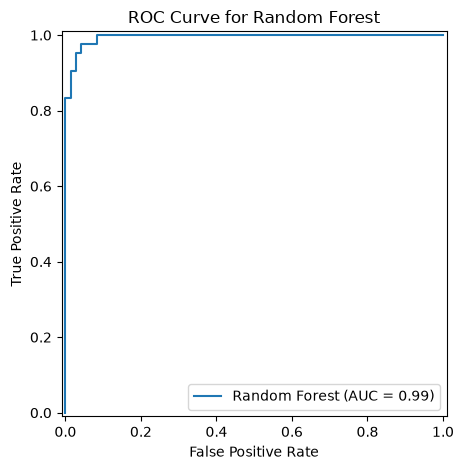

In [165]:
RocCurveDisplay.from_predictions(
    y_test,
    random_forest_malignant_probabilities,
    name="Random Forest"
)

plt.title("ROC Curve for Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

In [166]:
random_forest_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

random_forest_feature_importance = (
    random_forest_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

random_forest_feature_importance.head(10).style.format({
    "Importance": "{:.4f}"
})

,Feature,Importance
0,perimeter_worst,0.1699
1,area_worst,0.1267
2,radius_worst,0.1063
3,concave_points_worst,0.0999
4,concave_points_mean,0.0904
5,area_mean,0.0588
6,perimeter_mean,0.0542
7,concavity_mean,0.0489
8,radius_mean,0.0459
9,concavity_worst,0.0270


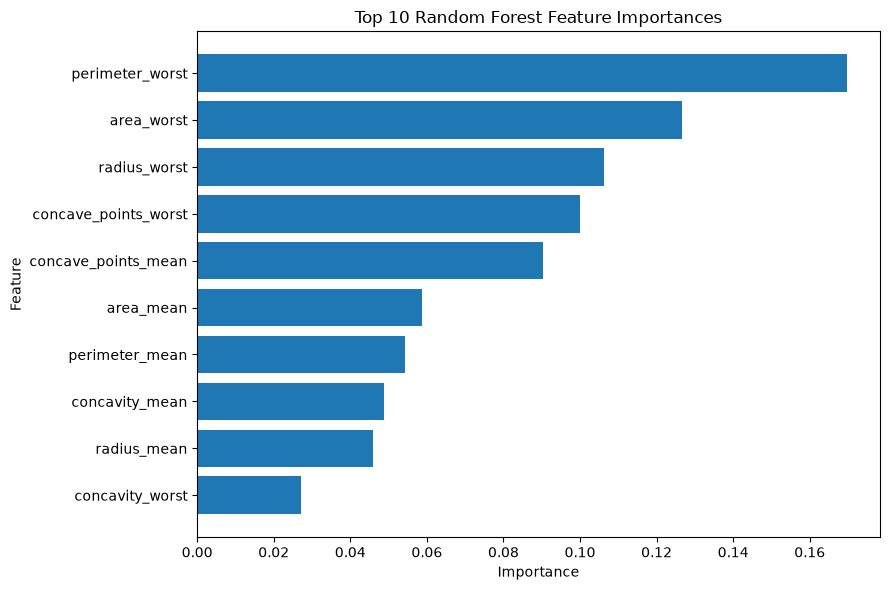

In [167]:
top_random_forest_features = (
    random_forest_feature_importance.head(10)
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_random_forest_features["Feature"][::-1],
    top_random_forest_features["Importance"][::-1]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature-Importance Observation

The feature-importance chart shows which measurements contributed most to the
Random Forest predictions. A higher value indicates that a feature was used more
effectively across the ensemble's decision splits. Feature importance indicates
predictive contribution but does not establish a causal relationship.

In [168]:
model_comparison_results

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.973684,0.997354,0.975610,0.952381,0.963855,0.943340
1,Decision Tree,0.938596,0.910714,0.972973,0.857143,0.911392,0.868766
2,kNN,0.973684,0.971396,1.000000,0.928571,0.962963,0.944155
3,Naive Bayes,0.938596,0.989749,0.948718,0.880952,0.913580,0.867493


In [169]:
model_comparison_results = pd.concat(
    [
        model_comparison_results,
        random_forest_metrics_df
    ],
    ignore_index=True
)

In [170]:
model_comparison_results = (
    model_comparison_results
    .drop_duplicates(
        subset=["ML Model Name"],
        keep="last"
    )
    .reset_index(drop=True)
)

In [171]:
model_comparison_results.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688
2,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442
3,Naive Bayes,0.9386,0.9897,0.9487,0.8810,0.9136,0.8675
4,Random Forest,0.9561,0.9947,0.9512,0.9286,0.9398,0.9054


In [172]:
random_forest_observation = (
    f"Random Forest used 200 Decision Trees and achieved an accuracy "
    f"of {random_forest_accuracy:.4f}, an AUC score of "
    f"{random_forest_auc:.4f}, a precision of "
    f"{random_forest_precision:.4f}, a recall of "
    f"{random_forest_recall:.4f}, an F1 score of "
    f"{random_forest_f1:.4f}, and an MCC score of "
    f"{random_forest_mcc:.4f}. The confusion matrix contained "
    f"{random_forest_false_negatives} false-negative malignant cases."
)

print(random_forest_observation)

Random Forest used 200 Decision Trees and achieved an accuracy of 0.9561, an AUC score of 0.9947, a precision of 0.9512, a recall of 0.9286, an F1 score of 0.9398, and an MCC score of 0.9054. The confusion matrix contained 3 false-negative malignant cases.


## Random Forest Performance Observation

Random Forest was implemented using 200 Decision Trees. Each tree was trained
using bootstrap sampling and a random subset of features, which provides model
diversity and reduces dependence on any individual tree.

The model achieved an accuracy of **0.9561**, an AUC score of
**0.9947**, a precision of **0.9512**, a recall of
**0.9286**, an F1 score of **0.9398**, and an MCC score of
**0.9054**.

The confusion matrix showed **3** malignant cases
incorrectly classified as benign. Random Forest generally produces more stable
predictions than a single Decision Tree because the final prediction is aggregated
across multiple trees.

In [173]:
print("RANDOM FOREST IMPLEMENTATION SUMMARY")
print("=" * 60)
print("Model source file        : model/random_forest.py")
print("Model source available   :", RANDOM_FOREST_SOURCE_PATH.exists())
print("Model type               : Ensemble classifier")
print("Number of trees          :", random_forest_model.n_estimators)
print("Feature scaling          : No")
print("Bootstrap sampling       :", random_forest_model.bootstrap)
print("Maximum features         :", random_forest_model.max_features)
print("Training instances       :", X_train.shape[0])
print("Testing instances        :", X_test.shape[0])
print("Input features           :", X_train.shape[1])
print("Positive class           : Malignant")
print("Positive-class encoding  : 1")
print("-" * 60)
print(f"Accuracy                  : {random_forest_accuracy:.4f}")
print(f"AUC                       : {random_forest_auc:.4f}")
print(f"Precision                 : {random_forest_precision:.4f}")
print(f"Recall                    : {random_forest_recall:.4f}")
print(f"F1 Score                  : {random_forest_f1:.4f}")
print(f"MCC                       : {random_forest_mcc:.4f}")
print("-" * 60)
print("True Negatives           :", random_forest_true_negatives)
print("False Positives          :", random_forest_false_positives)
print("False Negatives          :", random_forest_false_negatives)
print("True Positives           :", random_forest_true_positives)
print("=" * 60)
print("Random Forest implementation completed successfully.")

RANDOM FOREST IMPLEMENTATION SUMMARY
Model source file        : model/random_forest.py
Model source available   : True
Model type               : Ensemble classifier
Number of trees          : 200
Feature scaling          : No
Bootstrap sampling       : True
Maximum features         : sqrt
Training instances       : 455
Testing instances        : 114
Input features           : 30
Positive class           : Malignant
Positive-class encoding  : 1
------------------------------------------------------------
Accuracy                  : 0.9561
AUC                       : 0.9947
Precision                 : 0.9512
Recall                    : 0.9286
F1 Score                  : 0.9398
MCC                       : 0.9054
------------------------------------------------------------
True Negatives           : 70
False Positives          : 2
False Negatives          : 3
True Positives           : 39
Random Forest implementation completed successfully.


# Final Model Comparison and Overall Winner

All five classification models were trained and evaluated using the same training
and testing datasets. This ensures that the performance comparison is fair and
consistent.

The models are compared using Accuracy, AUC, Precision, Recall, F1 score, and
Matthews Correlation Coefficient. Since the positive class represents malignant
cases, recall and false-negative count are also considered when interpreting the
results.

In [174]:
required_metric_variables = [
    "logistic_accuracy",
    "logistic_auc",
    "logistic_precision",
    "logistic_recall",
    "logistic_f1",
    "logistic_mcc",

    "decision_tree_accuracy",
    "decision_tree_auc",
    "decision_tree_precision",
    "decision_tree_recall",
    "decision_tree_f1",
    "decision_tree_mcc",

    "knn_accuracy",
    "knn_auc",
    "knn_precision",
    "knn_recall",
    "knn_f1",
    "knn_mcc",

    "naive_bayes_accuracy",
    "naive_bayes_auc",
    "naive_bayes_precision",
    "naive_bayes_recall",
    "naive_bayes_f1",
    "naive_bayes_mcc",

    "random_forest_accuracy",
    "random_forest_auc",
    "random_forest_precision",
    "random_forest_recall",
    "random_forest_f1",
    "random_forest_mcc"
]

missing_metric_variables = [
    variable_name
    for variable_name in required_metric_variables
    if variable_name not in globals()
]

if missing_metric_variables:
    print("The following metric variables are missing:")

    for variable_name in missing_metric_variables:
        print("-", variable_name)

    raise NameError(
        "Run the model evaluation cells for the missing variables "
        "before creating the final comparison table."
    )

print("All metric variables are available.")


All metric variables are available.


In [175]:
import pandas as pd

model_comparison_results = pd.DataFrame({
    "ML Model Name": [
        "Logistic Regression",
        "Decision Tree",
        "kNN",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        knn_accuracy,
        naive_bayes_accuracy,
        random_forest_accuracy
    ],
    "AUC": [
        logistic_auc,
        decision_tree_auc,
        knn_auc,
        naive_bayes_auc,
        random_forest_auc
    ],
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        knn_precision,
        naive_bayes_precision,
        random_forest_precision
    ],
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        knn_recall,
        naive_bayes_recall,
        random_forest_recall
    ],
    "F1": [
        logistic_f1,
        decision_tree_f1,
        knn_f1,
        naive_bayes_f1,
        random_forest_f1
    ],
    "MCC": [
        logistic_mcc,
        decision_tree_mcc,
        knn_mcc,
        naive_bayes_mcc,
        random_forest_mcc
    ]
})

print("Final model comparison table created successfully.")

Final model comparison table created successfully.


In [176]:
model_comparison_results.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688
2,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442
3,Naive Bayes,0.9386,0.9897,0.9487,0.8810,0.9136,0.8675
4,Random Forest,0.9561,0.9947,0.9512,0.9286,0.9398,0.9054


In [177]:
required_error_variables = [
    "logistic_false_positives",
    "logistic_false_negatives",
    "decision_tree_false_positives",
    "decision_tree_false_negatives",
    "knn_false_positives",
    "knn_false_negatives",
    "naive_bayes_false_positives",
    "naive_bayes_false_negatives",
    "random_forest_false_positives",
    "random_forest_false_negatives"
]

missing_error_variables = [
    variable_name
    for variable_name in required_error_variables
    if variable_name not in globals()
]

if missing_error_variables:
    print("Missing confusion-matrix variables:")

    for variable_name in missing_error_variables:
        print("-", variable_name)

    raise NameError(
        "Run the confusion-matrix cells for the missing models."
    )

print("All confusion-matrix error variables are available.")

All confusion-matrix error variables are available.


In [178]:
extended_model_comparison = (
    model_comparison_results.copy()
)

extended_model_comparison["False Positives"] = [
    logistic_false_positives,
    decision_tree_false_positives,
    knn_false_positives,
    naive_bayes_false_positives,
    random_forest_false_positives
]

extended_model_comparison["False Negatives"] = [
    logistic_false_negatives,
    decision_tree_false_negatives,
    knn_false_negatives,
    naive_bayes_false_negatives,
    random_forest_false_negatives
]

extended_model_comparison.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}",
    "False Positives": "{:.0f}",
    "False Negatives": "{:.0f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC,False Positives,False Negatives
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433,1,2
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688,1,6
2,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442,0,3
3,Naive Bayes,0.9386,0.9897,0.9487,0.8810,0.9136,0.8675,2,5
4,Random Forest,0.9561,0.9947,0.9512,0.9286,0.9398,0.9054,2,3


In [191]:
import pandas as pd

false_negative_counts = pd.DataFrame({
    "ML Model Name": [
        "Logistic Regression",
        "Decision Tree",
        "kNN",
        "Naive Bayes",
        "Random Forest"
    ],

    "False Negatives": [
        logistic_false_negatives,
        decision_tree_false_negatives,
        knn_false_negatives,
        naive_bayes_false_negatives,
        random_forest_false_negatives
    ]
})

false_negative_counts

,ML Model Name,False Negatives
0,Logistic Regression,2
1,Decision Tree,6
2,kNN,3
3,Naive Bayes,5
4,Random Forest,3


In [192]:
model_ranking_results = (
    model_comparison_results.copy()
)
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]
for metric_name in metric_columns:
    model_ranking_results[f"{metric_name} Rank"] = (
        model_ranking_results[metric_name]
        .rank(
            ascending=False,
            method="min"
        )
    )

rank_columns = [
    "Accuracy Rank",
    "AUC Rank",
    "Precision Rank",
    "Recall Rank",
    "F1 Rank",
    "MCC Rank"
]

model_ranking_results["Average Rank"] = (
    model_ranking_results[rank_columns]
    .mean(axis=1)
)

model_ranking_results.style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}",
    "Accuracy Rank": "{:.0f}",
    "AUC Rank": "{:.0f}",
    "Precision Rank": "{:.0f}",
    "Recall Rank": "{:.0f}",
    "F1 Rank": "{:.0f}",
    "MCC Rank": "{:.0f}",
    "Average Rank": "{:.2f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC,Accuracy Rank,AUC Rank,Precision Rank,Recall Rank,F1 Rank,MCC Rank,Average Rank
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433,1,1,2,1,1,2,1.33
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688,4,5,3,5,5,4,4.33
2,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442,1,4,1,2,2,1,1.83
3,Naive Bayes,0.9386,0.9897,0.9487,0.8810,0.9136,0.8675,4,3,5,4,4,5,4.17
4,Random Forest,0.9561,0.9947,0.9512,0.9286,0.9398,0.9054,3,2,4,2,3,3,2.83


In [201]:
final_winner_analysis = pd.merge(
    model_ranking_results,
    false_negative_counts,
    on="ML Model Name",
    how="left"
)


In [202]:
final_winner_analysis = (
    final_winner_analysis
    .sort_values(
        by=[
            "Average Rank",
            "MCC",
            "F1",
            "AUC",
            "Recall",
            "False Negatives"
        ],
        ascending=[
            True,
            False,
            False,
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

final_winner_analysis[
    [
        "ML Model Name",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1",
        "MCC",
        "False Negatives",
        "Average Rank"
    ]
].style.format({
    "Accuracy": "{:.4f}",
    "AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "MCC": "{:.4f}",
    "False Negatives": "{:.0f}",
    "Average Rank": "{:.2f}"
})

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC,False Negatives,Average Rank
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433,2,1.33
1,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442,3,1.83
2,Random Forest,0.9561,0.9947,0.9512,0.9286,0.9398,0.9054,3,2.83
3,Naive Bayes,0.9386,0.9897,0.9487,0.8810,0.9136,0.8675,5,4.17
4,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688,6,4.33


In [203]:
overall_winner_row = final_winner_analysis.iloc[0]

overall_winner_name = overall_winner_row[
    "ML Model Name"
]

print("Overall winning model:", overall_winner_name)
print(
    "Average metric rank:",
    f"{overall_winner_row['Average Rank']:.2f}"
)
print(
    "False negatives:",
    int(overall_winner_row["False Negatives"])
)

Overall winning model: Logistic Regression
Average metric rank: 1.33
False negatives: 2


In [204]:
model_ranking_summary = (
    model_ranking_results[
        [
            "ML Model Name",
            "Accuracy Rank",
            "AUC Rank",
            "Precision Rank",
            "Recall Rank",
            "F1 Rank",
            "MCC Rank",
            "Average Rank"
        ]
    ]
    .sort_values(
        by=[
            "Average Rank",
            "MCC Rank",
            "F1 Rank",
            "AUC Rank"
        ],
        ascending=True
    )
    .reset_index(drop=True)
)

model_ranking_summary.style.format({
    "Accuracy Rank": "{:.0f}",
    "AUC Rank": "{:.0f}",
    "Precision Rank": "{:.0f}",
    "Recall Rank": "{:.0f}",
    "F1 Rank": "{:.0f}",
    "MCC Rank": "{:.0f}",
    "Average Rank": "{:.2f}"
})

,ML Model Name,Accuracy Rank,AUC Rank,Precision Rank,Recall Rank,F1 Rank,MCC Rank,Average Rank
0,Logistic Regression,1,1,2,1,1,2,1.33
1,kNN,1,4,1,2,2,1,1.83
2,Random Forest,3,2,4,2,3,3,2.83
3,Naive Bayes,4,3,5,4,4,5,4.17
4,Decision Tree,4,5,3,5,5,4,4.33


In [205]:
import pandas as pd

# Evaluation metrics used for comparing all models
metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]


# Function to identify the best model for a selected metric
def find_best_models(comparison_df, metric_name):
    highest_value = comparison_df[metric_name].max()

    best_models = comparison_df.loc[
        comparison_df[metric_name] == highest_value,
        "ML Model Name"
    ].tolist()

    return highest_value, best_models


# Store the winner details for every metric
metric_winner_records = []

for metric_name in metric_columns:
    highest_value, best_models = find_best_models(
        model_comparison_results,
        metric_name
    )

    winner_record = {
        "Metric": metric_name,
        "Best Model": ", ".join(best_models),
        "Best Score": highest_value
    }

    metric_winner_records.append(winner_record)


# Convert the winner records into a DataFrame
metric_winners_df = pd.DataFrame(metric_winner_records)


# Display the result with four decimal places
metric_winners_df.style.format({
    "Best Score": "{:.4f}"
})

,Metric,Best Model,Best Score
0,Accuracy,"Logistic Regression, kNN",0.9737
1,AUC,Logistic Regression,0.9974
2,Precision,kNN,1.0000
3,Recall,Logistic Regression,0.9524
4,F1,Logistic Regression,0.9639
5,MCC,kNN,0.9442


In [206]:
print("BEST MODEL FOR EACH EVALUATION METRIC")
print("=" * 65)

for _, winner_row in metric_winners_df.iterrows():
    metric_name = winner_row["Metric"]
    best_model_name = winner_row["Best Model"]
    best_score = winner_row["Best Score"]

    print(
        f"{metric_name:<10}: "
        f"{best_model_name} "
        f"({best_score:.4f})"
    )

print("=" * 65)

BEST MODEL FOR EACH EVALUATION METRIC
Accuracy  : Logistic Regression, kNN (0.9737)
AUC       : Logistic Regression (0.9974)
Precision : kNN (1.0000)
Recall    : Logistic Regression (0.9524)
F1        : Logistic Regression (0.9639)
MCC       : kNN (0.9442)


In [207]:
assert metric_winners_df.shape == (6, 3), (
    "The winner table should contain six rows and three columns."
)

assert metric_winners_df["Metric"].tolist() == [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
], "The metric order is incorrect."

assert metric_winners_df["Best Model"].notna().all(), (
    "A winning model is missing for one or more metrics."
)

assert metric_winners_df["Best Score"].notna().all(), (
    "A winning score is missing for one or more metrics."
)

print("Metric-winner table validation passed successfully.")

Metric-winner table validation passed successfully.


In [208]:
readme_metric_table = model_comparison_results.copy()

readme_metric_table["ML Model Name"] = (
    readme_metric_table["ML Model Name"]
    .replace({
        "Random Forest": "Random Forest (Ensemble)"
    })
)

metric_columns_for_readme = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

readme_metric_table[
    metric_columns_for_readme
] = (
    readme_metric_table[
        metric_columns_for_readme
    ]
    .round(4)
)

readme_metric_table


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9756,0.9524,0.9639,0.9433
1,Decision Tree,0.9386,0.9107,0.9730,0.8571,0.9114,0.8688
2,kNN,0.9737,0.9714,1.0000,0.9286,0.9630,0.9442
3,Naive Bayes,0.9386,0.9897,0.9487,0.8810,0.9136,0.8675
4,Random Forest (Ensemble),0.9561,0.9947,0.9512,0.9286,0.9398,0.9054


In [209]:
!python -m pip install tabulate
print(
    readme_metric_table.to_markdown(
        index=False
    )
)

| ML Model Name            |   Accuracy |    AUC |   Precision |   Recall |     F1 |    MCC |
|:-------------------------|-----------:|-------:|------------:|---------:|-------:|-------:|
| Logistic Regression      |     0.9737 | 0.9974 |      0.9756 |   0.9524 | 0.9639 | 0.9433 |
| Decision Tree            |     0.9386 | 0.9107 |      0.973  |   0.8571 | 0.9114 | 0.8688 |
| kNN                      |     0.9737 | 0.9714 |      1      |   0.9286 | 0.963  | 0.9442 |
| Naive Bayes              |     0.9386 | 0.9897 |      0.9487 |   0.881  | 0.9136 | 0.8675 |
| Random Forest (Ensemble) |     0.9561 | 0.9947 |      0.9512 |   0.9286 | 0.9398 | 0.9054 |


In [211]:
model_observation_table = pd.DataFrame({
    "ML Model Name": [
        "Logistic Regression",
        "Decision Tree",
        "kNN",
        "Naive Bayes",
        "Random Forest (Ensemble)",
        "Overall Winner for the Dataset"
    ],

    "Observation about Model Performance": [
        (
            f"Logistic Regression achieved an Accuracy of "
            f"{logistic_accuracy:.4f}, AUC of {logistic_auc:.4f}, "
            f"Precision of {logistic_precision:.4f}, Recall of "
            f"{logistic_recall:.4f}, F1 Score of {logistic_f1:.4f}, "
            f"and MCC of {logistic_mcc:.4f}. Feature standardization "
            f"helped the model process measurements with different "
            f"numerical scales. The model produced "
            f"{logistic_false_negatives} false-negative prediction(s)."
        ),

        (
            f"Decision Tree achieved an Accuracy of "
            f"{decision_tree_accuracy:.4f}, AUC of "
            f"{decision_tree_auc:.4f}, Precision of "
            f"{decision_tree_precision:.4f}, Recall of "
            f"{decision_tree_recall:.4f}, F1 Score of "
            f"{decision_tree_f1:.4f}, and MCC of "
            f"{decision_tree_mcc:.4f}. The classifier learned "
            f"threshold-based rules without feature scaling. Tree-depth "
            f"and leaf-size restrictions were used to reduce overfitting. "
            f"The model produced {decision_tree_false_negatives} "
            f"false-negative prediction(s)."
        ),

        (
            f"kNN achieved an Accuracy of {knn_accuracy:.4f}, "
            f"AUC of {knn_auc:.4f}, Precision of "
            f"{knn_precision:.4f}, Recall of {knn_recall:.4f}, "
            f"F1 Score of {knn_f1:.4f}, and MCC of {knn_mcc:.4f}. "
            f"StandardScaler was used because kNN calculates distances "
            f"between observations. The model used five nearest neighbors "
            f"and produced {knn_false_negatives} false-negative "
            f"prediction(s)."
        ),

        (
            f"Gaussian Naive Bayes achieved an Accuracy of "
            f"{naive_bayes_accuracy:.4f}, AUC of "
            f"{naive_bayes_auc:.4f}, Precision of "
            f"{naive_bayes_precision:.4f}, Recall of "
            f"{naive_bayes_recall:.4f}, F1 Score of "
            f"{naive_bayes_f1:.4f}, and MCC of "
            f"{naive_bayes_mcc:.4f}. The model was computationally "
            f"efficient, although the conditional-independence assumption "
            f"may be restrictive. The model produced "
            f"{naive_bayes_false_negatives} false-negative prediction(s)."
        ),

        (
            f"Random Forest achieved an Accuracy of "
            f"{random_forest_accuracy:.4f}, AUC of "
            f"{random_forest_auc:.4f}, Precision of "
            f"{random_forest_precision:.4f}, Recall of "
            f"{random_forest_recall:.4f}, F1 Score of "
            f"{random_forest_f1:.4f}, and MCC of "
            f"{random_forest_mcc:.4f}. The ensemble combined predictions "
            f"from 200 Decision Trees, improving stability and capturing "
            f"nonlinear relationships. The model produced "
            f"{random_forest_false_negatives} false-negative prediction(s)."
        ),

        (
            f"{overall_winner_name} was selected as the overall winner "
            f"based on combined performance across Accuracy, AUC, "
            f"Precision, Recall, F1 Score, and MCC. The model achieved "
            f"an average metric rank of "
            f"{overall_winner_row['Average Rank']:.2f} and produced "
            f"{int(overall_winner_row['False Negatives'])} false-negative "
            f"prediction(s). The winner was selected using multiple "
            f"evaluation measures rather than Accuracy alone."
        )
    ]
})

model_observation_table

,ML Model Name,Observation about Model Performance
0,Logistic Regression,Logistic Regression achieved an Accuracy of 0....
1,Decision Tree,"Decision Tree achieved an Accuracy of 0.9386, ..."
2,kNN,"kNN achieved an Accuracy of 0.9737, AUC of 0.9..."
3,Naive Bayes,Gaussian Naive Bayes achieved an Accuracy of 0...
4,Random Forest (Ensemble),"Random Forest achieved an Accuracy of 0.9561, ..."
5,Overall Winner for the Dataset,Logistic Regression was selected as the overal...


In [213]:
print(
    model_observation_table.to_markdown(
        index=False
    )
)

| ML Model Name                  | Observation about Model Performance                                                                                                                                                                                                                                                                                                        |
|:-------------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Logistic Regression            | Logistic Regression achieved an Accuracy of 0.9737, AUC of 0.9974, Precision of 0.9756, Recall of 0.9524, F1 Score of 0.9639, and MCC of 0.9433. Feature standardization helped the model process measurements with different numeric